# Explore Results

In [71]:
import os
os.environ["MNE_3D_BACKEND"] = "pyvistaqt"

# Ensure notebook backend is impossible
os.environ.pop("PYVISTA_BACKEND", None)
os.environ.pop("PYVISTA_OFF_SCREEN", None)

In [72]:
import wheel
import pandas as pd
import numpy as np
import sklearn as skl
from mat4py import loadmat
import scipy.io
import csv
import struct
import os
import h5py
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from helpers.constants import *
from mne_bids import BIDSPath, read_raw_bids
from scipy.signal import butter, filtfilt
from mne.time_frequency import tfr_multitaper
import scipy
from scipy.stats import mannwhitneyu, wilcoxon, ttest_ind, permutation_test
import seaborn as sb
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import tkinter as tk
import warnings
import collections
from mne.datasets import fetch_fsaverage
from scipy import stats
from itertools import combinations
import seaborn as sns
from sklearn.metrics import r2_score



In [73]:
import mne
from mne.viz import plot_alignment, snapshot_brain_montage
from mne.transforms import apply_trans
from mne.surface import read_surface
from helpers.constants import *


In [74]:
"""
Results structure:
return {
        'bert_results': bert_results,
        'gpt_results': gpt_results,
        't5_results': t5_results,
        'bert_model': bert_model, <- so I can look at evals
        'gpt_model': gpt_model,<- so I can look at evals
        't5_model': t5_model,<- so I can look at evals
        'y': y, <- neural data
        'groups': groups
    }
"""

"\nResults structure:\nreturn {\n        'bert_results': bert_results,\n        'gpt_results': gpt_results,\n        't5_results': t5_results,\n        'bert_model': bert_model, <- so I can look at evals\n        'gpt_model': gpt_model,<- so I can look at evals\n        't5_model': t5_model,<- so I can look at evals\n        'y': y, <- neural data\n        'groups': groups\n    }\n"

In [75]:
%matplotlib inline
mne.viz.set_3d_backend('notebook')

'notebook'

In [76]:
"""
To use to notebook the following files are needed (So far files are only generated for subject 8 and 14 but more files can be created
using matlab scripts) 
-elecFinal table
-Python friendly converted tables (tables and strings are converted to cell arrays, every is converted to structs to avoid opaque issues)
-HDR, CurrState, Record, Trig-List raw, Trig-list sentence field
First module sets up the task data, second part visualizes electrodes, can comment everything above the h5py line if only neurological 
processing is needed
-Also change the variable Gen_Path to your local directory, Subject to the subject you want and Sub_Num to that subjects number
"""

'\nTo use to notebook the following files are needed (So far files are only generated for subject 8 and 14 but more files can be created\nusing matlab scripts) \n-elecFinal table\n-Python friendly converted tables (tables and strings are converted to cell arrays, every is converted to structs to avoid opaque issues)\n-HDR, CurrState, Record, Trig-List raw, Trig-list sentence field\nFirst module sets up the task data, second part visualizes electrodes, can comment everything above the h5py line if only neurological \nprocessing is needed\n-Also change the variable Gen_Path to your local directory, Subject to the subject you want and Sub_Num to that subjects number\n'

## Initializing Electrode Storage

In [77]:
elec_path = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat" #This will stay static for every participant once its changed to the correct path                          

In [78]:
elec_raw = scipy.io.loadmat(elec_path, squeeze_me=True, simplify_cells = True, struct_as_record = False)

In [79]:
elec_frame = pd.DataFrame(elec_raw['elec_out'])

In [80]:
subjects_dir = EXPANSION_PATH 

## Brain Plotting

In [81]:

def plot_electrodes_on_brain(electrode_data, metric='test_R_2', threshold=0.1,
                             subjects_dir=None, save_path=None, 
                             show_labels=True, view_angles=None):
    """
    Plot significant electrodes on fsaverage brain with color-coded performance.
    
    Parameters:
    -----------
    electrode_data : pd.DataFrame
        Combined dataframe with electrode info (from saved_elecs)
        Must have columns: 'groupAvgCoords', metric (e.g., 'test_R_2'), 
        'parcLabel', 'model', 'condition'
    metric : str
        Metric to use for color-coding ('test_R_2' or 'test_R')
    threshold : float
        Minimum metric value to display electrode
    subjects_dir : str, optional
        Path to FreeSurfer subjects directory
    save_path : str, optional
        Path to save figure
    show_labels : bool
        Whether to show brain parcellation labels
    view_angles : dict, optional
        Dictionary with azimuth, elevation, focalpoint for view
        
    Returns:
    --------
    brain : mne.viz.Brain object
        Brain visualization object
    sig_elecs : pd.DataFrame
        Filtered significant electrodes
    """
    
    # Setup subjects directory
    if subjects_dir is None:
        sample_path = mne.datasets.sample.data_path()
        subjects_dir = sample_path / "subjects"
        fetch_fsaverage(subjects_dir=subjects_dir, verbose=False)
    
    # Filter to significant electrodes
    sig_elecs = electrode_data[electrode_data[metric] >= threshold].copy()
    
    if len(sig_elecs) == 0:
        print(f"No electrodes above threshold {threshold}")
        return None, None
    
    print(f"Plotting {len(sig_elecs)} electrodes above threshold {threshold}")
    
    # Extract coordinates
    coordinates = np.array([list(row['groupAvgCoords']) for _, row in sig_elecs.iterrows()])
    coordinates = coordinates.astype(float)
    
    # Get metric values for color mapping
    metric_values = sig_elecs[metric].values
    
    # Normalize metric values to [0, 1] for color mapping
    metric_norm = (metric_values - metric_values.min()) / (metric_values.max() - metric_values.min())
    
    # Create color map (blue = low, red = high)
    import matplotlib.cm as cm
    cmap = cm.get_cmap('RdYlBu_r')  # Red-Yellow-Blue reversed (red=high performance)
    colors = [cmap(val) for val in metric_norm]
    
    # Create brain visualization
    brain = mne.viz.Brain(
        "fsaverage",
        hemi="both",
        surf="pial",
        subjects_dir=subjects_dir,
        background="white",
        cortex="classic",
        alpha=0.2,
        show=True,   # <-- SAFE NOW
    )

    
    # Set view
    if view_angles is None:
        view_angles = dict(azimuth=105, elevation=100, focalpoint=(0, 0, -15))
    brain.show_view(distance=400, **view_angles)
    
    # Add electrodes with color coding
    for i, (coord, color, val) in enumerate(zip(coordinates, colors, metric_values)):
        # Scale size by performance
        scale = 0.15 + (metric_norm[i] * 0.3)  # Size between 0.15 and 0.45
        brain.add_foci(
            coord.reshape(1, -1), 
            coords_as_verts=False, 
            hemi='vol', 
            color=color[:3],  # RGB only
            scale_factor=scale
        )
    
    # Add parcellation labels if requested
    if show_labels:
        atlas = 'aparc'
        for hemi in ['lh', 'rh']:
            labels = mne.read_labels_from_annot(
                'fsaverage', atlas, hemi=hemi, 
                subjects_dir=subjects_dir, verbose=False
            )
            for label in labels:
                if label.name != 'unknown':
                    brain.add_label(label, color=label.color, alpha=0.3)
    
    

    size_legend = (
        "Electrode size ∝ performance\n"
        f"min = {metric_values.min():.2f}\n"
        f"max = {metric_values.max():.2f}"
    )

    brain._renderer.plotter.add_text(
        size_legend,
        position="lower_left",
        font_size=10,
        color="black",
    )

    brain._renderer.plotter.add_text(
    f"fsaverage | {metric} ≥ {threshold}\nN={len(sig_elecs)} electrodes",
    position="upper_left",
    font_size=14,
    color="black",
    )
    title = (
        f"fsaverage | {metric} ≥ {threshold}\n"
        f"N = {len(sig_elecs)} electrodes"
    )
   


    # Ensure rendering before screenshot
    brain._renderer.plotter.render()

    if save_path is not None:
        brain._renderer.plotter.screenshot(save_path)

    
    # Print summary
    print("\n" + "="*60)
    print("BRAIN VISUALIZATION SUMMARY")
    print("="*60)
    print(f"Electrodes plotted: {len(sig_elecs)}")
    print(f"Metric range: {metric_values.min():.3f} - {metric_values.max():.3f}")
    print(f"\nTop 5 brain regions:")
    region_counts = sig_elecs['parcLabel'].value_counts().head(5)
    for region, count in region_counts.items():
        print(f"  {region}: {count} electrodes")
    
    return brain, sig_elecs



In [ ]:

def plot_electrodes_by_model(saved_elecs, subject_num, metric='test_R_2', 
                             threshold=0.1, subjects_dir=None, 
                             output_dir='results/brain_plots'):
    """
    Create separate brain visualizations for each model (BERT, GPT, T5).
    
    Features:
    - Separate 3D brain plot for each model
    - Electrodes color-coded by performance (red=high, blue=low)
    - Size scaled by R² value
    - Brain parcellation labels overlay
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary
    subject_num : int
        Subject number
    metric : str
        Metric to use for filtering ('test_R_2' or 'test_R')
    threshold : float
        Minimum metric value to display
    subjects_dir : str, optional
        FreeSurfer subjects directory
    output_dir : str
        Directory to save plots
    """
    
    if subject_num not in saved_elecs:
        print(f"Subject {subject_num} not found")
        return
    
    # Setup
    if subjects_dir is None:
        sample_path = mne.datasets.sample.data_path()
        subjects_dir = sample_path / "subjects"
        fetch_fsaverage(subjects_dir=subjects_dir, verbose=False)
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Combine all electrode data
    all_data = pd.concat(saved_elecs[subject_num], ignore_index=True)
    sig_data = all_data[all_data[metric] >= threshold]
    
    print(f"\n{'='*80}")
    print(f"BRAIN VISUALIZATIONS BY MODEL - SUBJECT {subject_num}")
    print('='*80)
    
    # Plot for each model
    for model in ['BERT', 'GPT', 'T5']:
        model_data = sig_data[sig_data['model'] == model]
        
        if len(model_data) == 0:
            print(f"\nNo significant electrodes for {model}")
            continue
        
        print(f"\n{model}: {len(model_data)} electrodes")
        
        brain, filtered = plot_electrodes_on_brain(
            model_data,
            metric=metric,
            threshold=threshold,
            subjects_dir=subjects_dir,
            save_path=f'{output_dir}/S{subject_num}_{model}_brain.png',
            show_labels=True
        )
        
        if brain is not None:
            brain.close()


In [83]:

def plot_electrodes_by_condition(saved_elecs, subject_num, metric='test_R_2',
                                 threshold=0.1, subjects_dir=None,
                                 output_dir='results/brain_plots'):
    """
    Create separate brain visualizations for each condition.
    
    Features:
    - Separate 3D brain plot for each experimental condition
    - Shows which brain regions are active per condition
    - Same color-coding and sizing as model plots
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary
    subject_num : int
        Subject number
    metric : str
        Metric to use for filtering
    threshold : float
        Minimum metric value to display
    subjects_dir : str, optional
        FreeSurfer subjects directory
    output_dir : str
        Directory to save plots
    """
    
    if subject_num not in saved_elecs:
        print(f"Subject {subject_num} not found")
        return
    
    if subjects_dir is None:
        sample_path = mne.datasets.sample.data_path()
        subjects_dir = sample_path / "subjects"
        fetch_fsaverage(subjects_dir=subjects_dir, verbose=False)
    
    os.makedirs(output_dir, exist_ok=True)
    
    all_data = pd.concat(saved_elecs[subject_num], ignore_index=True)
    sig_data = all_data[all_data[metric] >= threshold]
    
    print(f"\n{'='*80}")
    print(f"BRAIN VISUALIZATIONS BY CONDITION - SUBJECT {subject_num}")
    print('='*80)
    
    for condition in sig_data['condition'].unique():
        cond_data = sig_data[sig_data['condition'] == condition]
        
        print(f"\n{condition}: {len(cond_data)} electrodes")
        
        brain, filtered = plot_electrodes_on_brain(
            cond_data,
            metric=metric,
            threshold=threshold,
            subjects_dir=subjects_dir,
            save_path=f'{output_dir}/S{subject_num}_{condition}_brain.png',
            show_labels=True
        )
        
        # if brain is not None:
        #     brain.close()


In [84]:


def plot_brain_heatmap_by_region(saved_elecs, subject_num, metric='test_R_2',
                                 threshold=0.1, save_path=None):
    """
    Create a heatmap showing average performance by brain region.
    
    Features:
    - 2D heatmap with brain regions (rows) × models (columns)
    - Color represents mean R² in that region for that model
    - Annotations show electrode count per region/model
    - Regions sorted by average performance
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary
    subject_num : int
        Subject number
    metric : str
        Metric to aggregate ('test_R_2' or 'test_R')
    threshold : float
        Minimum metric value to include
    save_path : str, optional
        Path to save figure
        
    Returns:
    --------
    heatmap_data : pd.DataFrame
        Pivot table of mean metric by region and model
    """
    
    if subject_num not in saved_elecs:
        print(f"Subject {subject_num} not found")
        return None
    
    # Combine all data
    all_data = pd.concat(saved_elecs[subject_num], ignore_index=True)
    sig_data = all_data[all_data[metric] >= threshold]
    
    # Aggregate by brain region and model
    region_summary = sig_data.groupby(['parcLabel', 'model'])[metric].agg(['mean', 'count']).reset_index()
    
    # Pivot for heatmap
    heatmap_data = region_summary.pivot(index='parcLabel', columns='model', values='mean')
    count_data = region_summary.pivot(index='parcLabel', columns='model', values='count')
    
    # Sort by average performance
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop('avg', axis=1)
    count_data = count_data.reindex(heatmap_data.index)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_data) * 0.4)))
    
    # Create heatmap
    sns.heatmap(
        heatmap_data, 
        annot=True, 
        fmt='.3f', 
        cmap='RdYlBu_r',
        cbar_kws={'label': f'{metric}'},
        linewidths=0.5,
        ax=ax,
        vmin=threshold,
        vmax=heatmap_data.max().max()
    )
    
    ax.set_title(f'Subject {subject_num} - Mean {metric} by Brain Region', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Brain Region', fontsize=12, fontweight='bold')
    
    # Add count annotations
    for i, region in enumerate(heatmap_data.index):
        for j, model in enumerate(heatmap_data.columns):
            if region in count_data.index and model in count_data.columns:
                count = count_data.loc[region, model]
                if not pd.isna(count):
                    # Determine text color based on background
                    bg_value = heatmap_data.iloc[i, j]
                    text_color = 'white' if bg_value > 0.15 else 'black'
                    ax.text(j + 0.5, i + 0.7, f'n={int(count)}', 
                           ha='center', va='center', fontsize=8, 
                           color=text_color, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print(f"BRAIN REGION SUMMARY - SUBJECT {subject_num}")
    print("="*60)
    print(f"\nTop 10 regions by average {metric}:")
    region_avg = sig_data.groupby('parcLabel')[metric].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(region_avg.head(10).to_string())
    
    return heatmap_data

In [85]:


def generate_all_brain_visualizations(saved_elecs, subjects_run, 
                                      metric='test_R_2', threshold=0.1,
                                      subjects_dir=None):
    """
    Generate comprehensive brain visualizations for all subjects.
    
    This is the main function to call - it generates all three types of visualizations:
    1. Brain plots by model (BERT, GPT, T5)
    2. Brain plots by condition (overall, a, v, NGNS, GNS, GS)
    3. Regional heatmaps
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary from the main analysis
    subjects_run : list
        List of subject numbers to visualize
    metric : str
        Metric to use ('test_R_2' or 'test_R')
    threshold : float
        Minimum metric value to display (default 0.1)
    subjects_dir : str, optional
        Path to FreeSurfer subjects directory
        
    Usage:
    ------
    # Simple usage with defaults
    generate_all_brain_visualizations(saved_elecs, [1, 8, 12])
    
    # With custom threshold
    generate_all_brain_visualizations(saved_elecs, [1, 8, 12], threshold=0.15)
    """
    
    for sub in subjects_run:
        print(f"\n{'='*80}")
        print(f"GENERATING BRAIN VISUALIZATIONS - SUBJECT {sub}")
        print('='*80)
        
        output_dir = f'results/brain_plots/S{sub}'
        os.makedirs(output_dir, exist_ok=True)
        
        # 1. Electrodes by model
        print("\n1. Creating brain plots by model...")
        plot_electrodes_by_model(
            saved_elecs, 
            sub, 
            metric=metric,
            threshold=threshold,
            subjects_dir=subjects_dir,
            output_dir=output_dir
        )
        
        # 2. Electrodes by condition
        print("\n2. Creating brain plots by condition...")
        plot_electrodes_by_condition(
            saved_elecs,
            sub,
            metric=metric,
            threshold=threshold,
            subjects_dir=subjects_dir,
            output_dir=output_dir
        )
        
        # 3. Regional heatmap
        print("\n3. Creating brain region heatmap...")
        plot_brain_heatmap_by_region(
            saved_elecs,
            sub,
            metric=metric,
            threshold=threshold,
            save_path=f'{output_dir}/region_heatmap.png'
        )
        
        print(f"\n{'='*80}")
        print(f"All brain visualizations saved to: {output_dir}")
        print('='*80)



## Helper Functions

In [86]:
def find_files_with_pattern(start_dir, pattern):
    """
    Recursively finds all files matching a specific pattern within a directory.

    Args:
        start_dir (str): The root directory to start the search.
        pattern (str): The filename pattern to match (e.g., '*.txt', 'config_*.json').

    Returns:
        list: A list of absolute paths to the matching files.
    """
    matching_files = []
    # os.walk yields a tuple: (current_path, directories in current_path, files in current_path)
    for root, _, files in os.walk(start_dir):
        for filename in files:
            # Check if the filename matches the pattern
            if pattern in filename:
                # Construct the full path and add to the list
                full_path = os.path.join(root, filename)
                matching_files.append(full_path)
    return matching_files

In [87]:
def check_r2_tolerance(train_r2, test_r2, rel_threshold=25, abs_threshold=0.06):
    rel_diff = abs((test_r2 - train_r2) / train_r2) * 100
    abs_diff = abs(test_r2 - train_r2)
    return rel_diff <= rel_threshold or abs_diff <= abs_threshold

In [88]:
def pretty_print_df(name, df, max_rows=8):
    print(f"\n{'─'*12} {name} (n={len(df)}) {'─'*12}")
    if df.empty:
        print("No rows after filtering.")
    else:
        print(df.head(max_rows).to_string(index=False))
        if len(df) > max_rows:
            print(f"... ({len(df) - max_rows} more rows)")


In [89]:
def generate_all_electrodes(dict_conds, subject_data):
    """Generate structure with ALL electrodes (no filtering)"""
    all_electrodes = []
    for condition, frame in dict_conds.items():
        bert_df = pd.DataFrame(frame['bert_results'])
        gpt_df = pd.DataFrame(frame['gpt_results'])
        t5_df = pd.DataFrame(frame['t5_results'])

        bert_merge = pd.merge(
            bert_df,
            subject_data,
            left_index=True,
            right_on='Elec_index',
            how='inner'
        )
        gpt_merge = pd.merge(
            gpt_df,
            subject_data,
            left_index=True,
            right_on='Elec_index',
            how='inner'
        )
        t5_merge = pd.merge(
            t5_df,
            subject_data,
            left_index=True,
            right_on='Elec_index',
            how='inner'
        )
        
        bert_merge["condition"] = condition
        bert_merge["model"] = "BERT"
        all_electrodes.append(bert_merge)
        
        gpt_merge["condition"] = condition
        gpt_merge["model"] = "GPT"
        all_electrodes.append(gpt_merge)
        
        t5_merge["condition"] = condition
        t5_merge["model"] = "T5"
        all_electrodes.append(t5_merge)
    
    return all_electrodes

In [90]:
def generate_electrode_summary(dict_conds, subject_data):
    significant = []
    for condition,frame in dict_conds.items():
        bert_df = pd.DataFrame(frame['bert_results'])
        gpt_df = pd.DataFrame(frame['gpt_results'])
        t5_df = pd.DataFrame(frame['t5_results'])

        bert_merge = pd.merge(
        bert_df,
        subject_data,
        left_index=True,   # Use df1's index
        right_on='Elec_index', # Use a specific column in df2
        how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
        )
        gpt_merge = pd.merge(
            gpt_df,
            subject_data,
            left_index=True,   # Use df1's index
            right_on='Elec_index', # Use a specific column in df2
            how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
        )

        t5_merge = pd.merge(
            t5_df,
            subject_data,
            left_index=True,   # Use df1's index
            right_on='Elec_index', # Use a specific column in df2
            how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
        )
        #Filter to only electrodes with baseline model explainability:
        bert_merge = bert_merge[bert_merge['test_R_2'] >= 0.1]
        gpt_merge = gpt_merge[gpt_merge['test_R_2'] >= 0.1]
        t5_merge = t5_merge[t5_merge['test_R_2'] >= 0.1]

        if len(bert_merge) > 0 or len(gpt_merge) > 0 or len(t5_merge) > 0:
              print(" \n PROCESSING CONDITION: ", condition.upper()) #Only list significant conditions
        if len(bert_merge) > 0:
            bert_merge["condition"] = condition
            bert_merge["model"] = "BERT"
            significant.append(bert_merge)
            print()
            pretty_print_df("BERT", bert_merge)
        if len(gpt_merge) > 0:
            gpt_merge["condition"] = condition
            gpt_merge["model"] = "GPT"
            print()
            pretty_print_df("GPT", gpt_merge)
            significant.append(gpt_merge)
        if len(t5_merge) > 0:
            t5_merge["condition"] = condition
            t5_merge["model"] = "T5"
            print()
            pretty_print_df("T5", t5_merge)
            significant.append(t5_merge)
    return significant


In [91]:
def permutation_test_electrodes(further_filter_elecs, saved_elecs, n_permutations=10000):
    """
    Permutation test to check if filtered electrodes have significantly better
    R² values compared to all electrodes.
    
    Parameters:
    - further_filter_elecs: dict with filtered electrodes (train-test tolerance passed)
    - saved_elecs: dict with all significant electrodes
    - n_permutations: number of permutation iterations
    
    Returns:
    - results dictionary with p-values and effect sizes
    """
    results = {}
    
    for sub in further_filter_elecs.keys():
        print(f"\nRunning permutation test for Subject {sub}")
        
        # Get filtered and all electrodes
        filtered = further_filter_elecs[sub]
        all_elecs = saved_elecs[sub]
        
        n_filtered = len(filtered)
        n_all = len(all_elecs)
        
        if n_filtered == 0:
            print(f"No filtered electrodes for subject {sub}")
            continue
        
        # Extract test R² values
        filtered_r2 = np.array([elec['test_R_2'].values[0] for elec in filtered])
        all_r2 = np.array([elec['test_R_2'].values[0] for elec in all_elecs])
        
        # Observed test statistic (mean difference)
        observed_mean_filtered = np.mean(filtered_r2)
        observed_mean_all = np.mean(all_r2)
        observed_diff = observed_mean_filtered - observed_mean_all
        
        # Permutation test
        perm_diffs = []
        for _ in range(n_permutations):
            # Randomly sample n_filtered electrodes from all electrodes
            perm_sample = np.random.choice(all_r2, size=n_filtered, replace=False)
            perm_diff = np.mean(perm_sample) - observed_mean_all
            perm_diffs.append(perm_diff)
        
        perm_diffs = np.array(perm_diffs)
        
        # Calculate p-value (two-tailed)
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((n_filtered - 1) * np.var(filtered_r2) + 
                              (n_all - 1) * np.var(all_r2)) / (n_filtered + n_all - 2))
        cohens_d = observed_diff / pooled_std if pooled_std > 0 else 0
        
        results[sub] = {
            'n_filtered': n_filtered,
            'n_all': n_all,
            'mean_filtered_r2': observed_mean_filtered,
            'mean_all_r2': observed_mean_all,
            'mean_difference': observed_diff,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.05
        }
        
        print(f"  N filtered: {n_filtered}, N all: {n_all}")
        print(f"  Mean R² (filtered): {observed_mean_filtered:.4f}")
        print(f"  Mean R² (all): {observed_mean_all:.4f}")
        print(f"  Difference: {observed_diff:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Cohen's d: {cohens_d:.4f}")
        print(f"  Significant: {p_value < 0.05}")
    
    return results

In [92]:

# Alternative: Test if train-test consistency is better
def permutation_test_consistency(further_filter_elecs, saved_elecs, n_permutations=10000):
    """
    Test if filtered electrodes have better train-test consistency
    """
    results = {}
    
    for sub in further_filter_elecs.keys():
        filtered = further_filter_elecs[sub]
        all_elecs = saved_elecs[sub]
        
        n_filtered = len(filtered)
        
        if n_filtered == 0:
            continue
        
        # Calculate train-test differences
        filtered_diffs = np.array([
            abs(elec['test_R_2'].values[0] - elec['train_R_2'].values[0]) 
            for elec in filtered
        ])
        all_diffs = np.array([
            abs(elec['test_R_2'].values[0] - elec['train_R_2'].values[0]) 
            for elec in all_elecs
        ])
        
        observed_mean_diff = np.mean(filtered_diffs) - np.mean(all_diffs)
        
        # Permutation
        perm_diffs = []
        for _ in range(n_permutations):
            perm_sample = np.random.choice(all_diffs, size=n_filtered, replace=False)
            perm_diffs.append(np.mean(perm_sample) - np.mean(all_diffs))
        
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_mean_diff))
        
        results[sub] = {
            'mean_consistency_filtered': np.mean(filtered_diffs),
            'mean_consistency_all': np.mean(all_diffs),
            'p_value': p_value,
            'significant': p_value < 0.05
        }
    
    return results

## Graphing

In [93]:

def reconstruct_predictions_from_model(results_dict, model_name='bert'):
    """
    Reconstruct train/test predictions from your saved model objects.
    This extracts the predictions that were used to compute R² scores.
    
    Parameters:
    -----------
    results_dict : dict
        Your results dictionary from run_ridge_regression_sliding_window
    model_name : str
        'bert', 'gpt', or 't5'
    
    Returns:
    --------
    dict with train/test predictions and actual values per electrode
    """
    model_key = f'{model_name}_model'
    
    if model_key not in results_dict:
        print(f"Model {model_name} not found in results")
        return None
    
    model = results_dict[model_key]
    y = results_dict['y']  # (n_trials, n_electrodes)
    groups = results_dict['groups']
    
    # Get train/test split
    # Note: You'll need to recreate X_train, X_test from embeddings
    # For now, we'll use the stored model to get predictions
    
    print(f"Extracting predictions for {model_name}")
    print(f"  Model type: {type(model).__name__}")
    print(f"  Y shape: {y.shape}")
    print(f"  Groups shape: {groups.shape if hasattr(groups, 'shape') else len(groups)}")
    
    # The model should have train/test predictions stored or we can regenerate
    # For now, return the structure we need
    return {
        'model': model,
        'y': y,
        'groups': groups,
        'n_electrodes': y.shape[1]
    }

In [94]:



def plot_predictions_vs_actual_from_saved(results_dict, electrode_idx, 
                                          X_dict, model_name='bert',
                                          n_samples=500, save_path=None):
    """
    Plot model predictions against actual neural data using saved results.
    
    Parameters:
    -----------
    results_dict : dict
        Results from run_ridge_regression_sliding_window
    electrode_idx : int
        Index of electrode to visualize
    X_dict : dict
        Dictionary with 'X_train', 'X_test' keys (you'll need to compute this)
    model_name : str
        'bert', 'gpt', or 't5'
    n_samples : int
        Number of samples to plot
    save_path : str, optional
        Path to save figure
    """
    
    model_key = f'{model_name}_model'
    model = results_dict[model_key]
    y = results_dict['y']
    
    # Get predictions
    if 'X_train' not in X_dict or 'X_test' not in X_dict:
        print("ERROR: Need X_train and X_test in X_dict")
        print("See add_predictions_to_pipeline() function below for how to save these")
        return
    
    X_train = X_dict['X_train']
    X_test = X_dict['X_test']
    y_train = X_dict['y_train']
    y_test = X_dict['y_test']
    
    # Generate predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Extract data for this electrode
    y_train_actual = y_train[:, electrode_idx]
    y_train_predicted = y_train_pred[:, electrode_idx]
    y_test_actual = y_test[:, electrode_idx]
    y_test_predicted = y_test_pred[:, electrode_idx]
    
    # Limit samples for plotting
    n_train_samples = min(n_samples, len(y_train_actual))
    n_test_samples = min(n_samples, len(y_test_actual))
    
    # Calculate R² for display
    train_r2 = r2_score(y_train_actual, y_train_predicted)
    test_r2 = r2_score(y_test_actual, y_test_predicted)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Time series comparison (train)
    ax = axes[0, 0]
    ax.plot(y_train_actual[:n_train_samples], label='Actual', alpha=0.7, linewidth=1.5, color='blue')
    ax.plot(y_train_predicted[:n_train_samples], label='Predicted', alpha=0.7, linewidth=1.5, color='red')
    ax.set_title(f'Training Data - Electrode {electrode_idx} ({model_name.upper()})', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Points')
    ax.set_ylabel('Neural Activity (Power)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.98, f'R² = {train_r2:.3f}', transform=ax.transAxes,
           verticalalignment='top', fontsize=10, 
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Plot 2: Time series comparison (test)
    ax = axes[0, 1]
    ax.plot(y_test_actual[:n_test_samples], label='Actual', alpha=0.7, linewidth=1.5, color='blue')
    ax.plot(y_test_predicted[:n_test_samples], label='Predicted', alpha=0.7, linewidth=1.5, color='red')
    ax.set_title(f'Test Data - Electrode {electrode_idx} ({model_name.upper()})', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Points')
    ax.set_ylabel('Neural Activity (Power)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.98, f'R² = {test_r2:.3f}', transform=ax.transAxes,
           verticalalignment='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Plot 3: Scatter plot (train)
    ax = axes[1, 0]
    ax.scatter(y_train_actual, y_train_predicted, alpha=0.4, s=20, color='steelblue')
    
    # Add regression line
    z = np.polyfit(y_train_actual, y_train_predicted, 1)
    p = np.poly1d(z)
    x_line = np.array([y_train_actual.min(), y_train_actual.max()])
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Fit line')
    
    # Add identity line
    ax.plot(x_line, x_line, 'k--', alpha=0.5, linewidth=1, label='Perfect fit')
    
    ax.set_xlabel('Actual Activity', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Activity', fontsize=11, fontweight='bold')
    ax.set_title('Train: Predicted vs Actual', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.95, f'R² = {train_r2:.3f}\nn = {len(y_train_actual)}', 
           transform=ax.transAxes, verticalalignment='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    # Plot 4: Scatter plot (test)
    ax = axes[1, 1]
    ax.scatter(y_test_actual, y_test_predicted, alpha=0.4, s=20, color='coral')
    
    # Add regression line
    z = np.polyfit(y_test_actual, y_test_predicted, 1)
    p = np.poly1d(z)
    x_line = np.array([y_test_actual.min(), y_test_actual.max()])
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Fit line')
    
    # Add identity line
    ax.plot(x_line, x_line, 'k--', alpha=0.5, linewidth=1, label='Perfect fit')
    
    ax.set_xlabel('Actual Activity', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Activity', fontsize=11, fontweight='bold')
    ax.set_title('Test: Predicted vs Actual', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.95, f'R² = {test_r2:.3f}\nn = {len(y_test_actual)}', 
           transform=ax.transAxes, verticalalignment='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Electrode {electrode_idx} - {model_name.upper()} Predictions")
    print('='*60)
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²:  {test_r2:.4f}")
    print(f"Generalization gap: {abs(train_r2 - test_r2):.4f}")
    print(f"Train samples: {len(y_train_actual)}")
    print(f"Test samples:  {len(y_test_actual)}")



In [95]:
"""
Frequency (Hz): Defines how fast a signal oscillates or repeats itself (e.g., alpha, beta, gamma bands). It represents the temporal rate of the brainwave.
Power (Magnitude squared): Defines how strong the signal is at a given frequency. It represents the intensity or amplitude of the activity. 
"""

'\nFrequency (Hz): Defines how fast a signal oscillates or repeats itself (e.g., alpha, beta, gamma bands). It represents the temporal rate of the brainwave.\nPower (Magnitude squared): Defines how strong the signal is at a given frequency. It represents the intensity or amplitude of the activity. \n'

In [96]:

def plot_spectrogram_from_y(y_data, electrode_idx, fs=1000, nperseg=256, 
                            title=None, save_path=None):
    """
    Create spectrogram of neural data for a specific electrode.
    
    Parameters:
    -----------
    y_data : np.array
        Neural data (n_trials, n_electrodes) - averaged power values
    electrode_idx : int
        Index of electrode to visualize
    fs : float
        Effective sampling frequency (for averaged data, this is conceptual)
    nperseg : int
        Length of each segment for STFT
    title : str, optional
        Custom title
    save_path : str, optional
        Path to save figure
    """
    
    # Extract data for this electrode
    data = y_data[:, electrode_idx]
    
    # Since your data is already averaged across time windows,
    # we'll create a different visualization
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot 1: Raw signal
    ax = axes[0]
    ax.plot(data, linewidth=1, alpha=0.8, color='steelblue')
    ax.set_ylabel('Power', fontsize=11, fontweight='bold')
    ax.set_title(title or f'Electrode {electrode_idx} - Trial-Averaged Power', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Trial Index')
    
    # Plot 2: Distribution
    ax = axes[1]
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(data):.3f}')
    ax.axvline(np.median(data), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(data):.3f}')
    ax.set_xlabel('Power', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Power Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Rolling statistics
    ax = axes[2]
    window = min(20, len(data) // 10)
    if window > 2:
        rolling_mean = pd.Series(data).rolling(window=window, center=True).mean()
        rolling_std = pd.Series(data).rolling(window=window, center=True).std()
        
        ax.plot(rolling_mean, label='Rolling Mean', linewidth=2, color='blue')
        ax.fill_between(range(len(data)), 
                        rolling_mean - rolling_std, 
                        rolling_mean + rolling_std,
                        alpha=0.3, color='blue', label='±1 SD')
        ax.set_xlabel('Trial Index', fontsize=11, fontweight='bold')
        ax.set_ylabel('Power', fontsize=11, fontweight='bold')
        ax.set_title(f'Rolling Statistics (window={window})', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Insufficient data for rolling statistics', 
               ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"Electrode {electrode_idx} - Power Statistics")
    print('='*60)
    print(f"Mean:   {np.mean(data):.4f}")
    print(f"Median: {np.median(data):.4f}")
    print(f"Std:    {np.std(data):.4f}")
    print(f"Min:    {np.min(data):.4f}")
    print(f"Max:    {np.max(data):.4f}")
    print(f"Range:  {np.max(data) - np.min(data):.4f}")



In [97]:

def plot_top_electrodes_summary(saved_elecs, subject_num, top_n=10, 
                                metric='test_R_2', save_path=None):
    """
    Create a comprehensive visualization of top-performing electrodes.
    Works with your saved_elecs structure.
    """
    if subject_num not in saved_elecs:
        print(f"Subject {subject_num} not found")
        return
    
    # Combine all electrode data
    all_elec_data = pd.concat(saved_elecs[subject_num], ignore_index=True)
    
    # Sort by performance metric
    top_elecs = all_elec_data.nlargest(top_n, metric)
    
    # Create figure
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Bar chart of top electrodes
    ax1 = fig.add_subplot(gs[0, :])
    x_pos = np.arange(len(top_elecs))
    colors_map = {'BERT': '#8dd3c7', 'GPT': '#fb8072', 'T5': '#80b1d3'}
    bar_colors = [colors_map.get(model, 'gray') for model in top_elecs['model']]
    
    bars = ax1.bar(x_pos, top_elecs[metric], color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    
    labels = [f"{row['electrode']}\n{row['model']}\n{row['condition']} {row['parcLabel']}" 
              for _, row in top_elecs.iterrows()]
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top {top_n} Electrodes - Subject {subject_num}', 
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold (0.1)')
    ax1.legend()
    
    for bar, val in zip(bars, top_elecs[metric]):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Train vs Test R²
    ax2 = fig.add_subplot(gs[1, 0])
    for model in top_elecs['model'].unique():
        model_data = top_elecs[top_elecs['model'] == model]
        ax2.scatter(model_data['train_R_2'], model_data['test_R_2'], 
                   label=model, alpha=0.6, s=100, edgecolors='black', linewidth=1)
    
    max_val = max(top_elecs['train_R_2'].max(), top_elecs['test_R_2'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1, label='Perfect generalization')
    
    ax2.set_xlabel('Train R²', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Test R²', fontsize=11, fontweight='bold')
    ax2.set_title('Generalization Check', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Model comparison
    ax3 = fig.add_subplot(gs[1, 1])
    model_summary = top_elecs.groupby('model')[metric].agg(['mean', 'std', 'count'])
    x_pos = np.arange(len(model_summary))
    
    bars = ax3.bar(x_pos, model_summary['mean'], 
                   yerr=model_summary['std'], capsize=5,
                   color=[colors_map.get(m, 'gray') for m in model_summary.index],
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(model_summary.index)
    ax3.set_ylabel(f'Mean {metric}', fontsize=11, fontweight='bold')
    ax3.set_title('Model Performance', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar, count in zip(bars, model_summary['count']):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'n={int(count)}', ha='center', va='bottom', fontsize=9)
    
    # Plot 4: Condition breakdown
    ax4 = fig.add_subplot(gs[2, 0])
    condition_summary = top_elecs.groupby(['condition', 'model']).size().unstack(fill_value=0)
    condition_summary.plot(kind='bar', ax=ax4, 
                          color=[colors_map.get(m, 'gray') for m in condition_summary.columns],
                          alpha=0.7, edgecolor='black', linewidth=1.5)
    ax4.set_xlabel('Condition', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax4.set_title('Distribution by Condition', fontsize=12, fontweight='bold')
    ax4.legend(title='Model')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: R² distribution
    ax5 = fig.add_subplot(gs[2, 1])
    for model in top_elecs['model'].unique():
        model_data = top_elecs[top_elecs['model'] == model]
        ax5.hist(model_data[metric], alpha=0.6, label=model, bins=10, 
                edgecolor='black', linewidth=1)
    ax5.set_xlabel('Test R²', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title('R² Distribution', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Subject {subject_num} - Top {top_n} Electrode Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"TOP {top_n} ELECTRODES SUMMARY - SUBJECT {subject_num}")
    print('='*80)
    print(f"\nMean Test R²: {top_elecs[metric].mean():.4f} ± {top_elecs[metric].std():.4f}")
    print(f"Range: {top_elecs[metric].min():.4f} - {top_elecs[metric].max():.4f}")
    print(f"\nModel Distribution:")
    print(top_elecs['model'].value_counts())
    print(f"\nCondition Distribution:")
    print(top_elecs['condition'].value_counts())
    
    return top_elecs


## Statistical Testing

In [98]:

def create_summary_table(results):
    """
    Create a summary table of statistical test results.
    """
    
    summary_data = []
    for sub, res in results.items():
        summary_data.append({
            'Subject': sub,
            'N (High-perf)': res['n_saved'],
            'N (All)': res['n_all'],
            'Mean (High-perf)': f"{res['mean_saved']:.4f}",
            'Mean (All)': f"{res['mean_all']:.4f}",
            'Difference': f"{res['mean_difference']:.4f}",
            'Cohen\'s d': f"{res['cohens_d']:.3f}",
            'Mann-Whitney p': f"{res['mannwhitney_p']:.4f}",
            't-test p': f"{res['ttest_p']:.4f}",
            'Permutation p': f"{res['permutation_p']:.4f}",
            'Significant?': 'Yes ***' if res['significant_perm'] else 'No'
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    return summary_df

In [99]:

def compare_saved_vs_all_electrodes(saved_elecs, all_elecs, metric='test_R_2'):
    """
    Compare high-performing electrodes (saved_elecs) vs all electrodes (all_elecs).
    
    Parameters:
    -----------
    saved_elecs : dict
        Dictionary with high-performing electrodes (R² > 0.1)
    all_elecs : dict
        Dictionary with ALL electrodes
    metric : str
        Metric to compare (default: 'test_R_2')
    
    Returns:
    --------
    results : dict
        Statistical test results for each subject
    """
    
    results = {}
    
    print("\n" + "="*80)
    print("STATISTICAL COMPARISON: HIGH-PERFORMING vs ALL ELECTRODES")
    print("="*80)
    
    for sub in saved_elecs.keys():
        print(f"\n{'='*80}")
        print(f"SUBJECT {sub}")
        print('='*80)
        
        # Combine dataframes
        saved_df = pd.concat(saved_elecs[sub], ignore_index=True)
        all_df = pd.concat(all_elecs[sub], ignore_index=True)
        
        # Extract metric values
        saved_values = saved_df[metric].values
        all_values = all_df[metric].values
        
        # Basic statistics
        print(f"\n{'='*60}")
        print("DESCRIPTIVE STATISTICS")
        print('='*60)
        print(f"High-performing electrodes (R² > 0.1):")
        print(f"  N = {len(saved_values)}")
        print(f"  Mean = {np.mean(saved_values):.4f}")
        print(f"  Median = {np.median(saved_values):.4f}")
        print(f"  SD = {np.std(saved_values):.4f}")
        print(f"  Range = [{np.min(saved_values):.4f}, {np.max(saved_values):.4f}]")
        
        print(f"\nAll electrodes:")
        print(f"  N = {len(all_values)}")
        print(f"  Mean = {np.mean(all_values):.4f}")
        print(f"  Median = {np.median(all_values):.4f}")
        print(f"  SD = {np.std(all_values):.4f}")
        print(f"  Range = [{np.min(all_values):.4f}, {np.max(all_values):.4f}]")
        
        print(f"\nDifference:")
        print(f"  Mean difference = {np.mean(saved_values) - np.mean(all_values):.4f}")
        print(f"  Median difference = {np.median(saved_values) - np.median(all_values):.4f}")
        
        # Statistical tests
        print(f"\n{'='*60}")
        print("STATISTICAL TESTS")
        print('='*60)
        
        # 1. Mann-Whitney U test (non-parametric, unpaired)
        stat_mw, p_mw = mannwhitneyu(saved_values, all_values, alternative='greater')
        
        # 2. Independent t-test (parametric, unpaired)
        stat_t, p_t = ttest_ind(saved_values, all_values, alternative='greater')
        
        # 3. Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(saved_values) - 1) * np.var(saved_values) + 
                              (len(all_values) - 1) * np.var(all_values)) / 
                              (len(saved_values) + len(all_values) - 2))
        cohens_d = (np.mean(saved_values) - np.mean(all_values)) / pooled_std
        
        # 4. Permutation test (most robust)
        def statistic(x, y, axis):
            return np.mean(x, axis=axis) - np.mean(y, axis=axis)
        
        perm_result = permutation_test(
            (saved_values, all_values),
            statistic,
            n_resamples=10000,
            alternative='greater',
            random_state=42
        )
        
        print(f"\n1. Mann-Whitney U Test (non-parametric):")
        print(f"   U-statistic = {stat_mw:.2f}")
        print(f"   p-value = {p_mw:.6f} {'***' if p_mw < 0.001 else '**' if p_mw < 0.01 else '*' if p_mw < 0.05 else 'ns'}")
        
        print(f"\n2. Independent t-test (parametric):")
        print(f"   t-statistic = {stat_t:.2f}")
        print(f"   p-value = {p_t:.6f} {'***' if p_t < 0.001 else '**' if p_t < 0.01 else '*' if p_t < 0.05 else 'ns'}")
        
        print(f"\n3. Effect Size:")
        print(f"   Cohen's d = {cohens_d:.4f}", end="")
        if abs(cohens_d) < 0.2:
            print(" (negligible)")
        elif abs(cohens_d) < 0.5:
            print(" (small)")
        elif abs(cohens_d) < 0.8:
            print(" (medium)")
        else:
            print(" (large)")
        
        print(f"\n4. Permutation Test (10,000 permutations):")
        print(f"   Observed difference = {perm_result.statistic:.4f}")
        print(f"   p-value = {perm_result.pvalue:.6f} {'***' if perm_result.pvalue < 0.001 else '**' if perm_result.pvalue < 0.01 else '*' if perm_result.pvalue < 0.05 else 'ns'}")
        
        # Store results
        results[sub] = {
            'n_saved': len(saved_values),
            'n_all': len(all_values),
            'mean_saved': np.mean(saved_values),
            'mean_all': np.mean(all_values),
            'median_saved': np.median(saved_values),
            'median_all': np.median(all_values),
            'std_saved': np.std(saved_values),
            'std_all': np.std(all_values),
            'mean_difference': np.mean(saved_values) - np.mean(all_values),
            'mannwhitney_u': stat_mw,
            'mannwhitney_p': p_mw,
            'ttest_t': stat_t,
            'ttest_p': p_t,
            'cohens_d': cohens_d,
            'permutation_p': perm_result.pvalue,
            'significant_mw': p_mw < 0.05,
            'significant_t': p_t < 0.05,
            'significant_perm': perm_result.pvalue < 0.05
        }
    
    return results

In [100]:
def visualize_saved_vs_all(saved_elecs, all_elecs, metric='test_R_2', save_path=None):
    """
    Create comprehensive visualizations comparing saved vs all electrodes.
    """
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    subjects = list(saved_elecs.keys())
    n_subjects = len(subjects)
    
    # Prepare data
    plot_data = []
    for sub in subjects:
        saved_df = pd.concat(saved_elecs[sub], ignore_index=True)
        all_df = pd.concat(all_elecs[sub], ignore_index=True)
        
        for _, row in saved_df.iterrows():
            plot_data.append({
                'subject': sub,
                'type': 'High-performing (R² > 0.1)',
                metric: row[metric],
                'model': row['model']
            })
        
        for _, row in all_df.iterrows():
            plot_data.append({
                'subject': sub,
                'type': 'All electrodes',
                metric: row[metric],
                'model': row['model']
            })
    
    df = pd.DataFrame(plot_data)
    
    # Plot 1: Overall distribution (box + violin)
    ax1 = fig.add_subplot(gs[0, :])
    
    # Violin plot
    parts = ax1.violinplot(
        [df[df['type'] == 'All electrodes'][metric].values,
         df[df['type'] == 'High-performing (R² > 0.1)'][metric].values],
        positions=[0, 1],
        widths=0.7,
        showmeans=True,
        showmedians=True
    )
    
    # Color the violins
    colors = ['lightblue', 'lightcoral']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['All Electrodes', 'High-Performing (R² > 0.1)'])
    ax1.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax1.set_title('Overall Distribution Comparison', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold')
    ax1.legend()
    
    # Plot 2: By subject
    ax2 = fig.add_subplot(gs[1, :])
    
    subject_order = sorted(df['subject'].unique())
    sns.boxplot(data=df, x='subject', y=metric, hue='type', ax=ax2, palette=['lightblue', 'lightcoral'])
    ax2.set_xlabel('Subject', fontsize=12, fontweight='bold')
    ax2.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax2.set_title('Distribution by Subject', fontsize=14, fontweight='bold')
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5)
    ax2.legend(title='Electrode Type')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Histogram comparison
    ax3 = fig.add_subplot(gs[2, 0])
    
    all_vals = df[df['type'] == 'All electrodes'][metric].values
    saved_vals = df[df['type'] == 'High-performing (R² > 0.1)'][metric].values
    
    ax3.hist(all_vals, bins=50, alpha=0.6, label='All', color='lightblue', density=True)
    ax3.hist(saved_vals, bins=30, alpha=0.6, label='High-performing', color='lightcoral', density=True)
    ax3.axvline(np.mean(all_vals), color='blue', linestyle='--', linewidth=2, label=f'Mean (All): {np.mean(all_vals):.3f}')
    ax3.axvline(np.mean(saved_vals), color='red', linestyle='--', linewidth=2, label=f'Mean (High): {np.mean(saved_vals):.3f}')
    ax3.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax3.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax3.set_title('Distribution Histogram', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Cumulative distribution
    ax4 = fig.add_subplot(gs[2, 1])
    
    sorted_all = np.sort(all_vals)
    sorted_saved = np.sort(saved_vals)
    
    ax4.plot(sorted_all, np.linspace(0, 1, len(sorted_all)), label='All', linewidth=2, color='blue')
    ax4.plot(sorted_saved, np.linspace(0, 1, len(sorted_saved)), label='High-performing', linewidth=2, color='red')
    ax4.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax4.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax4.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
    ax4.set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Model comparison
    ax5 = fig.add_subplot(gs[2, 2])
    
    model_summary = df.groupby(['model', 'type'])[metric].mean().reset_index()
    
    x = np.arange(len(model_summary['model'].unique()))
    width = 0.35
    
    all_means = model_summary[model_summary['type'] == 'All electrodes'][metric].values
    saved_means = model_summary[model_summary['type'] == 'High-performing (R² > 0.1)'][metric].values
    
    ax5.bar(x - width/2, all_means, width, label='All', color='lightblue', edgecolor='black')
    ax5.bar(x + width/2, saved_means, width, label='High-performing', color='lightcoral', edgecolor='black')
    
    ax5.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax5.set_ylabel(f'Mean {metric}', fontsize=11, fontweight='bold')
    ax5.set_title('By Model', fontsize=12, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(model_summary['model'].unique())
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'High-Performing vs All Electrodes Comparison', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [101]:
def run_full_comparison(saved_elecs, all_elecs, metric='test_R_2', 
                       save_dir='results/statistical_comparison'):
    """
    Run complete statistical comparison and generate all visualizations.
    
    Usage:
    ------
    results = run_full_comparison(saved_elecs, all_elecs)
    """
    
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    # Run statistical tests
    results = compare_saved_vs_all_electrodes(saved_elecs, all_elecs, metric=metric)
    
    # Create visualizations
    visualize_saved_vs_all(saved_elecs, all_elecs, metric=metric, 
                          save_path=f'{save_dir}/comparison_plots.png')
    
    # Create summary table
    summary_df = create_summary_table(results)
    summary_df.to_csv(f'{save_dir}/statistical_summary.csv', index=False)
    
    print(f"\n{'='*80}")
    print(f"All results saved to: {save_dir}")
    print('='*80)
    
    return results, summary_df

In [102]:

def prepare_model_data(saved_elecs):
    """
    Extract and organize data by model and condition from saved_elecs structure
    
    Parameters:
    -----------
    saved_elecs : dict
        Dictionary with subjects as keys, list of dataframes as values
        Each dataframe has a 'model' column (BERT, GPT, T5) and 'condition' column
    
    Returns:
    --------
    model_data : dict
        Dictionary with keys 'BERT', 'GPT-2', 'T5', each containing combined dataframes
    condition_data : dict
        Dictionary with condition names as keys, containing model comparisons
    """
    
    
    # Initialize containers
    bert_list = []
    gpt_list = []
    t5_list = []
    
    print("\n" + "="*80)
    print("ORGANIZING DATA BY MODEL")
    print("="*80)
    
    # Collect all dataframes by model
    for sub, dfs in saved_elecs.items():
        print(f"\nProcessing Subject {sub}:")
        for i, df in enumerate(dfs):
            # Check if 'model' column exists
            model = df['model'].iloc[0].upper()
            condition = df['condition'].iloc[0] if 'condition' in df.columns else 'unknown'
            n_rows = len(df)
            
            print(f"  DF {i}: Model={model}, Condition={condition}, Rows={n_rows}")
            
            if 'BERT' in model:
                bert_list.append(df)
            elif 'GPT' in model:
                gpt_list.append(df)
            elif 'T5' in model:
                t5_list.append(df)
    
    # Combine all data
    print("\n" + "="*80)
    print("COMBINING DATA BY MODEL")
    print("="*80)
    
    model_data = {}
    if bert_list:
        model_data['BERT'] = pd.concat(bert_list, ignore_index=True)
        print(f"  BERT: {len(bert_list)} dataframes combined -> {len(model_data['BERT'])} total rows")
        print(f"    Unique electrodes: {model_data['BERT']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['BERT']['condition'].nunique()}")
    if gpt_list:
        model_data['GPT-2'] = pd.concat(gpt_list, ignore_index=True)
        print(f"  GPT-2: {len(gpt_list)} dataframes combined -> {len(model_data['GPT-2'])} total rows")
        print(f"    Unique electrodes: {model_data['GPT-2']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['GPT-2']['condition'].nunique()}")
    if t5_list:
        model_data['T5'] = pd.concat(t5_list, ignore_index=True)
        print(f"  T5: {len(t5_list)} dataframes combined -> {len(model_data['T5'])} total rows")
        print(f"    Unique electrodes: {model_data['T5']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['T5']['condition'].nunique()}")
    
    # Organize by condition
    print("\n" + "="*80)
    print("ORGANIZING DATA BY CONDITION")
    print("="*80)
    
    all_dfs = bert_list + gpt_list + t5_list
    condition_data = {}
    
    for df in all_dfs:
        cond = df['condition'].iloc[0]
        if cond not in condition_data:
            condition_data[cond] = {'BERT': [], 'GPT-2': [], 'T5': []}
        
        # Determine model
        model = df['model'].iloc[0].upper()
        if 'BERT' in model:
            condition_data[cond]['BERT'].append(df)
        elif 'GPT' in model:
            condition_data[cond]['GPT-2'].append(df)
        elif 'T5' in model:
            condition_data[cond]['T5'].append(df)
    # Print condition summary
    print(f"\nFound {len(condition_data)} conditions:")
    for cond, model_dict in condition_data.items():
        total_elecs = 0
        details = []
        for model, dfs in model_dict.items():
            if dfs:
                n_elecs = sum(len(df) for df in dfs)
                total_elecs += n_elecs
                details.append(f"{model}:{n_elecs}")
        print(f"  {cond}: {total_elecs} total electrode-model combinations ({', '.join(details)})")
    
    return model_data, condition_data

In [103]:
def compare_conditions_within_models(condition_data, use_r2=True):
    """
    Test if each model performs significantly better in specific conditions
    
    Parameters:
    -----------
    condition_data : dict
        Dictionary with condition names as keys, containing dict of model lists
    use_r2 : bool
        If True, use R², else use R
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    print("\n" + "="*80)
    print(f"WITHIN-MODEL CONDITION COMPARISONS ({metric_name})")
    print("="*80)
    print("Testing if each model performs significantly better in certain conditions")
    print("="*80)
    
    # Organize data by model first
    model_condition_data = {'BERT': {}, 'GPT-2': {}, 'T5': {}}
    
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) > 0:
                combined = pd.concat(dfs, ignore_index=True)
                model_condition_data[model][cond] = combined[metric].values
    
    # Test each model separately
    for model in ['BERT', 'GPT-2', 'T5']:
        if len(model_condition_data[model]) == 0:
            continue
            
        print(f"\n{'='*80}")
        print(f"{model} - Condition Comparison")
        print('='*80)
        
        conditions = list(model_condition_data[model].keys())
        
        # Summary statistics
        print("\nCondition Summary:")
        print(f"{'Condition':<15} {'Mean':<10} {'Std':<10} {'Median':<10} {'N':<8}")
        print("-" * 60)
        for cond in conditions:
            data = model_condition_data[model][cond]
            print(f"{cond:<15} {np.mean(data):<10.4f} {np.std(data):<10.4f} "
                  f"{np.median(data):<10.4f} {len(data):<8}")
        
        # Pairwise comparisons between conditions
        if len(conditions) > 1:
            print("\nPairwise Comparisons (Mann-Whitney U test):")
            print(f"{'Comparison':<30} {'p-value':<12} {'Sig':<6} {'Effect Size (d)':<15} {'Mean Diff':<12}")
            print("-" * 90)
            
            for i, j in combinations(range(len(conditions)), 2):
                cond1, cond2 = conditions[i], conditions[j]
                data1 = model_condition_data[model][cond1]
                data2 = model_condition_data[model][cond2]
                
                # Mann-Whitney U test (unpaired)
                stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                # Effect size (Cohen's d)
                mean_diff = np.mean(data1) - np.mean(data2)
                pooled_std = np.sqrt((np.var(data1) + np.var(data2)) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
                
                comparison = f"{cond1} vs {cond2}"
                print(f"{comparison:<30} {p_value:<12.4f} {sig:<6} {cohens_d:<15.4f} {mean_diff:<12.4f}")
        
        # If more than 2 conditions, do overall test
        if len(conditions) > 2:
            print("\nOverall Test (Kruskal-Wallis H-test):")
            condition_values = [model_condition_data[model][c] for c in conditions]
            h_stat, p_value = stats.kruskal(*condition_values)
            sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
            print(f"  H-statistic: {h_stat:.4f}")
            print(f"  p-value: {p_value:.4f} {sig}")
            
            if p_value < 0.05:
                # Find best performing condition
                means = {cond: np.mean(model_condition_data[model][cond]) for cond in conditions}
                best_cond = max(means, key=means.get)
                print(f"\n  Best performing condition: {best_cond} (Mean {metric_name} = {means[best_cond]:.4f})")

In [104]:

def visualize_within_model_conditions(condition_data, use_r2=True):
    """
    Visualize performance differences across conditions for each model
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare data
    plot_data = []
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) > 0:
                combined = pd.concat(dfs, ignore_index=True)
                for _, row in combined.iterrows():
                    plot_data.append({
                        'condition': cond,
                        'model': model,
                        metric: row[metric]
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create separate plots for each model
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, model in enumerate(['BERT', 'GPT-2', 'T5']):
        model_data = plot_df[plot_df['model'] == model]
        
        if len(model_data) == 0:
            axes[idx].text(0.5, 0.5, f'No data for {model}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            continue
        
        # Box plot with swarm overlay
        sns.boxplot(data=model_data, x='condition', y=metric, ax=axes[idx], 
                   palette='Set2', width=0.6)
        sns.swarmplot(data=model_data, x='condition', y=metric, ax=axes[idx],
                     color='black', alpha=0.3, size=3)
        
        axes[idx].set_title(f'{model} - Performance by Condition', 
                           fontsize=14, fontweight='bold')
        axes[idx].set_ylabel(f'Test {metric_name}', fontsize=12)
        axes[idx].set_xlabel('Condition', fontsize=12)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add mean line
        means = model_data.groupby('condition')[metric].mean()
        for i, cond in enumerate(model_data['condition'].unique()):
            axes[idx].hlines(means[cond], i-0.3, i+0.3, colors='red', 
                           linestyles='solid', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [105]:

def compare_model_performance_r2(model_data, use_r2=True):
    """
    Compare overall performance across models using R² or R
    
    Parameters:
    -----------
    model_data : dict
        Dictionary with model names as keys, dataframes as values
    use_r2 : bool
        If True, use R² (test_R_2), else use R (test_R)
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare combined data
    models_data = []
    for name, df in model_data.items():
        temp = pd.DataFrame()
        temp[metric] = df[metric]
        temp['test_MSE'] = df['test_MSE']
        temp['model'] = name
        models_data.append(temp)
    
    if len(models_data) == 0:
        print("No model data to compare!")
        return
    
    combined = pd.concat(models_data, ignore_index=True)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Test R² or R
    sns.boxplot(data=combined, x='model', y=metric, ax=axes[0], palette='Set2')
    sns.swarmplot(data=combined, x='model', y=metric, ax=axes[0], 
                  color='black', alpha=0.3, size=3)
    axes[0].set_title(f'Test {metric_name} by Model', fontsize=14, fontweight='bold')
    axes[0].set_ylabel(f'Test {metric_name}', fontsize=12)
    axes[0].set_xlabel('Model', fontsize=12)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Test MSE
    sns.boxplot(data=combined, x='model', y='test_MSE', ax=axes[1], palette='Set2')
    sns.swarmplot(data=combined, x='model', y='test_MSE', ax=axes[1], 
                  color='black', alpha=0.3, size=3)
    axes[1].set_title('Test MSE by Model', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Test MSE', fontsize=12)
    axes[1].set_xlabel('Model', fontsize=12)
    axes[1].set_yscale("log")
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("="*80)
    print(f"MODEL PERFORMANCE SUMMARY ({metric_name})")
    print("="*80)
    for name, df in model_data.items():
        print(f"\n{name}:")
        print(f"  Mean Test {metric_name}: {df[metric].mean():.4f} ± {df[metric].std():.4f}")
        print(f"  Median Test {metric_name}: {df[metric].median():.4f}")
        print(f"  Mean Test MSE: {df['test_MSE'].mean():.4f} ± {df['test_MSE'].std():.4f}")
        print(f"  # Electrodes: {len(df)}")
        print(f"  # High performance ({metric_name} > 0.2): {(df[metric] > 0.2).sum()}")
    
    # Statistical comparison
    print("\n" + "="*80)
    print(f"PAIRWISE COMPARISONS (Wilcoxon signed-rank test on {metric_name})")
    print("="*80)
    
    model_names = list(model_data.keys())
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1 = model_data[name1][metric].values
        data2 = model_data[name2][metric].values
        
        # Ensure equal length for paired test
        min_len = min(len(data1), len(data2))
        stat, p_value = stats.wilcoxon(data1[:min_len], data2[:min_len])
        
        # Effect size (rank-biserial correlation)
        diff = data1[:min_len] - data2[:min_len]
        r = (np.sum(diff > 0) - np.sum(diff < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
        print(f"  Effect size (r): {r:.4f}")
        print(f"  Mean difference: {np.mean(diff):.4f}")

In [106]:

def compare_conditions(condition_data, use_r2=True):
    """
    Compare model performance across different conditions
    
    Parameters:
    -----------
    condition_data : dict
        Dictionary with condition names as keys, containing dict of model lists
    use_r2 : bool
        If True, use R², else use R
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare data for plotting
    plot_data = []
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) == 0:
                continue
                
            # Combine all dataframes for this model in this condition
            combined_df = pd.concat(dfs, ignore_index=True)
            
            for _, row in combined_df.iterrows():
                plot_data.append({
                    'condition': cond,
                    'model': model,
                    metric: row[metric],
                    'test_MSE': row['test_MSE']
                })
    
    if len(plot_data) == 0:
        print("No condition data to compare!")
        return
    
    plot_df = pd.DataFrame(plot_data)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Performance by condition
    sns.barplot(data=plot_df, x='condition', y=metric, hue='model', 
                ax=axes[0], palette='Set2', errorbar='se')
    axes[0].set_title(f'Model Performance by Condition ({metric_name})', 
                      fontsize=14, fontweight='bold')
    axes[0].set_ylabel(f'Mean Test {metric_name}', fontsize=12)
    axes[0].set_xlabel('Condition', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0].legend(title='Model')
    
    # Count of electrodes by condition
    condition_counts = plot_df.groupby(['condition', 'model']).size().reset_index(name='count')
    sns.barplot(data=condition_counts, x='condition', y='count', hue='model',
                ax=axes[1], palette='Set2')
    axes[1].set_title('Number of High-Preforming Electrodes (r^2 > 0.1) by Condition', 
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Electrodes', fontsize=12)
    axes[1].set_xlabel('Condition', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Model')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests per condition
    print("\n" + "="*80)
    print(f"CONDITION-SPECIFIC COMPARISONS ({metric_name})")
    print("="*80)
    
    unique_conditions = plot_df['condition'].unique()
    
    for cond in unique_conditions:
        print(f"\n{cond.upper()}:")
        cond_subset = plot_df[plot_df['condition'] == cond]
        
        models_in_cond = cond_subset['model'].unique()
        
        # Print summary stats
        for model in models_in_cond:
            model_data = cond_subset[cond_subset['model'] == model][metric]
            print(f"  {model}: Mean {metric_name} = {model_data.mean():.4f} ± {model_data.std():.4f} (n={len(model_data)})")
        
        # Pairwise tests
        if len(models_in_cond) > 1:
            print(f"\n  Pairwise comparisons:")
            for i, j in combinations(range(len(models_in_cond)), 2):
                m1, m2 = models_in_cond[i], models_in_cond[j]
                data1 = cond_subset[cond_subset['model'] == m1][metric].values
                data2 = cond_subset[cond_subset['model'] == m2][metric].values
                
                # Use Mann-Whitney U test (unpaired)
                stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                # Effect size (Cohen's d)
                mean_diff = np.mean(data1) - np.mean(data2)
                pooled_std = np.sqrt((np.var(data1) + np.var(data2)) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
                print(f"    {m1} vs {m2}: p={p_value:.4f} {sig}, d={cohens_d:.4f}")


In [107]:
def compare_r_vs_r2(model_data):
    """
    Compare whether R or R² is more powerful for detecting differences
    """
    
    print("\n" + "="*80)
    print("R vs R² STATISTICAL POWER COMPARISON")
    print("="*80)
    
    model_names = list(model_data.keys())
    
    print("\nEffect sizes and p-values using R:")
    print("-" * 80)
    
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1_r = model_data[name1]['test_R'].values
        data2_r = model_data[name2]['test_R'].values
        
        min_len = min(len(data1_r), len(data2_r))
        stat_r, p_r = stats.wilcoxon(data1_r[:min_len], data2_r[:min_len])
        
        # Effect size
        diff_r = data1_r[:min_len] - data2_r[:min_len]
        r_effect = (np.sum(diff_r > 0) - np.sum(diff_r < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  R:  p={p_r:.6f}, effect size={r_effect:.4f}, mean diff={np.mean(diff_r):.4f}")
    
    print("\nEffect sizes and p-values using R²:")
    print("-" * 80)
    
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1_r2 = model_data[name1]['test_R_2'].values
        data2_r2 = model_data[name2]['test_R_2'].values
        
        min_len = min(len(data1_r2), len(data2_r2))
        stat_r2, p_r2 = stats.wilcoxon(data1_r2[:min_len], data2_r2[:min_len])
        
        # Effect size
        diff_r2 = data1_r2[:min_len] - data2_r2[:min_len]
        r2_effect = (np.sum(diff_r2 > 0) - np.sum(diff_r2 < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  R²: p={p_r2:.6f}, effect size={r2_effect:.4f}, mean diff={np.mean(diff_r2):.4f}")


In [108]:
def run_comprehensive_analysis(saved_elecs):
    """
    Run all analyses on the saved_elecs data structure
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary from the pipeline
    """
    
    print("\n" + "="*80)
    print("PREPARING DATA")
    print("="*80)
    
    model_data, condition_data = prepare_model_data(saved_elecs)
    
    print(f"\nFound {len(model_data)} models:")
    for model, df in model_data.items():
        print(f"  {model}: {len(df)} electrodes")
    
    print(f"\nFound {len(condition_data)} conditions:")
    for cond, dfs in condition_data.items():
        n_elecs = sum(len(df) for df in dfs)
        print(f"  {cond}: {n_elecs} electrodes")
    
    # Run analyses
    print("\n" + "="*80)
    print("1. OVERALL MODEL PERFORMANCE (using R²)")
    print("="*80)
    compare_model_performance_r2(model_data, use_r2=True)
    
    print("\n" + "="*80)
    print("2. CONDITION-SPECIFIC ANALYSIS")
    print("="*80)
    compare_conditions(condition_data, use_r2=True)
    
    print("\n" + "="*80)
    print("3. WITHIN-MODEL CONDITION COMPARISONS")
    print("="*80)
    compare_conditions_within_models(condition_data, use_r2=True)
    visualize_within_model_conditions(condition_data, use_r2=True)
    
    print("\n" + "="*80)
    print("4. R vs R² POWER COMPARISON")
    print("="*80)
    compare_r_vs_r2(model_data)
    
    return model_data, condition_data

## Memory Management Fixes

In [109]:
if 'brain' in locals(): #helps avoid memory issues with brain model
    brain.close() 

In [110]:
plt.close('all')

In [111]:
warnings.filterwarnings('ignore')

## Subject Generation Loops

In [112]:
elec_counter = 0
saved_elecs = {}  # High-performing only
all_elecs = {}    # ALL electrodes
subjects_run = [1, 8, 12]

for sub in subjects_run:
    Subject = f"S{sub}"
    print(f"\n RUNNING SUBJECT {Subject}")
    Sub_num = sub
    Gen_Path = f"{EXPANSION_PATH}/Sub-Mat-Converted/{Subject}/"
    record_direc = DIRECTORYS[sub]

    # Filter Subject Data
    subject_elecs = elec_frame[(elec_frame['subjectNum'] == Sub_num) & 
                          (elec_frame['isRejectFSL'] != 1) & 
                          (elec_frame['isRejectManual'] != 1) & 
                          (elec_frame['isRejectFSL'] != 1)]
    
    subject_elecs["elecNum"] = subject_elecs["elecNum"].astype(int)
    subject_elecs["Elec_index"] = subject_elecs["elecNum"] - 1

    # Finding Subject Regression Results files
    sub_files = find_files_with_pattern("results_objs", f"S{sub}")

    # Creating loop_able dictionary
    conds_dict = {}
    for file_path in sub_files:
        data = pd.read_pickle(file_path)
        parts = file_path.split('_') 
        cond_name = parts[1].split('.')[0] 
        cond_name_final = parts[1].split('/')[-2]
        conds_dict[cond_name_final] = data
    
    # Generate BOTH filtered and unfiltered electrode sets
    all_elecs[sub] = generate_all_electrodes(conds_dict, subject_elecs)
    saved_elecs[sub] = generate_electrode_summary(conds_dict, subject_elecs)
    elec_counter += len(saved_elecs[sub])

print(f"Found {elec_counter} high-performing electrodes")
print(f"Total electrodes (all): {sum(len(all_elecs[sub]) for sub in all_elecs)}")




 RUNNING SUBJECT S1
 
 PROCESSING CONDITION:  GS


──────────── BERT (n=1) ────────────
   electrode  best_alpha  train_MSE  test_MSE  train_R   test_R  train_R_2  test_R_2  subjectNum  elecNum  isRejectManual   parcLabel                    ctxParc      wmParc  isRejectFSL_2wm  isRejectFSL  isWM  unknown_wmParc  groupLabels  isLeft                                              groupAvgCoords  Elec_index condition model
electrode_12       100.0   0.094144  0.048984 0.449937 0.361191    0.12378    0.1054           1       13               0 S_front_inf Left-Cerebral-White-Matter S_front_inf                0            0     1               0 LAI13 s1 e13       1 [-40.86806661504363, 29.39356787918851, 23.507254519203165]          12        GS  BERT


──────────── GPT (n=2) ────────────
   electrode  best_alpha  train_MSE  test_MSE  train_R   test_R  train_R_2  test_R_2  subjectNum  elecNum  isRejectManual          parcLabel                   ctxParc             wmParc  isRejectFSL_2wm  i


ANALYSIS ON ALL ELECTRODES
RUNNING SUBJECT 1

PREPARING DATA

ORGANIZING DATA BY MODEL

Processing Subject 1:
  DF 0: Model=BERT, Condition=GS, Rows=110
  DF 1: Model=GPT, Condition=GS, Rows=110
  DF 2: Model=T5, Condition=GS, Rows=110
  DF 3: Model=BERT, Condition=a, Rows=110
  DF 4: Model=GPT, Condition=a, Rows=110
  DF 5: Model=T5, Condition=a, Rows=110
  DF 6: Model=BERT, Condition=GNS, Rows=110
  DF 7: Model=GPT, Condition=GNS, Rows=110
  DF 8: Model=T5, Condition=GNS, Rows=110
  DF 9: Model=BERT, Condition=NGNS, Rows=110
  DF 10: Model=GPT, Condition=NGNS, Rows=110
  DF 11: Model=T5, Condition=NGNS, Rows=110
  DF 12: Model=BERT, Condition=v, Rows=110
  DF 13: Model=GPT, Condition=v, Rows=110
  DF 14: Model=T5, Condition=v, Rows=110
  DF 15: Model=BERT, Condition=overall, Rows=110
  DF 16: Model=GPT, Condition=overall, Rows=110
  DF 17: Model=T5, Condition=overall, Rows=110

COMBINING DATA BY MODEL
  BERT: 6 dataframes combined -> 660 total rows
    Unique electrodes: 110
    Uni

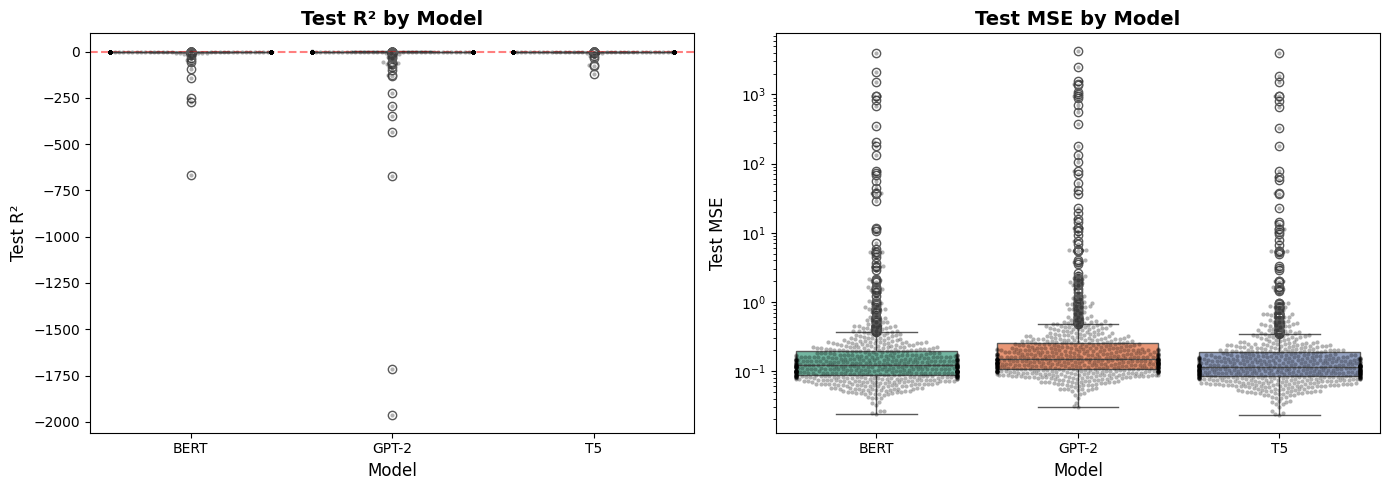

MODEL PERFORMANCE SUMMARY (R²)

BERT:
  Mean Test R²: -2.6305 ± 30.5256
  Median Test R²: -0.0472
  Mean Test MSE: 19.0990 ± 198.4038
  # Electrodes: 660
  # High performance (R² > 0.2): 1

GPT-2:
  Mean Test R²: -10.2078 ± 107.9666
  Median Test R²: -0.2800
  Mean Test MSE: 26.7299 ± 228.8330
  # Electrodes: 660
  # High performance (R² > 0.2): 2

T5:
  Mean Test R²: -0.6109 ± 6.4029
  Median Test R²: -0.0195
  Mean Test MSE: 17.8352 ± 193.6217
  # Electrodes: 660
  # High performance (R² > 0.2): 1

PAIRWISE COMPARISONS (Wilcoxon signed-rank test on R²)
BERT vs GPT-2:
  p-value: 0.0000 ***
  Effect size (r): 0.8576
  Mean difference: 7.5773
BERT vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.4182
  Mean difference: -2.0196
GPT-2 vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.8697
  Mean difference: -9.5969

2. CONDITION-SPECIFIC ANALYSIS


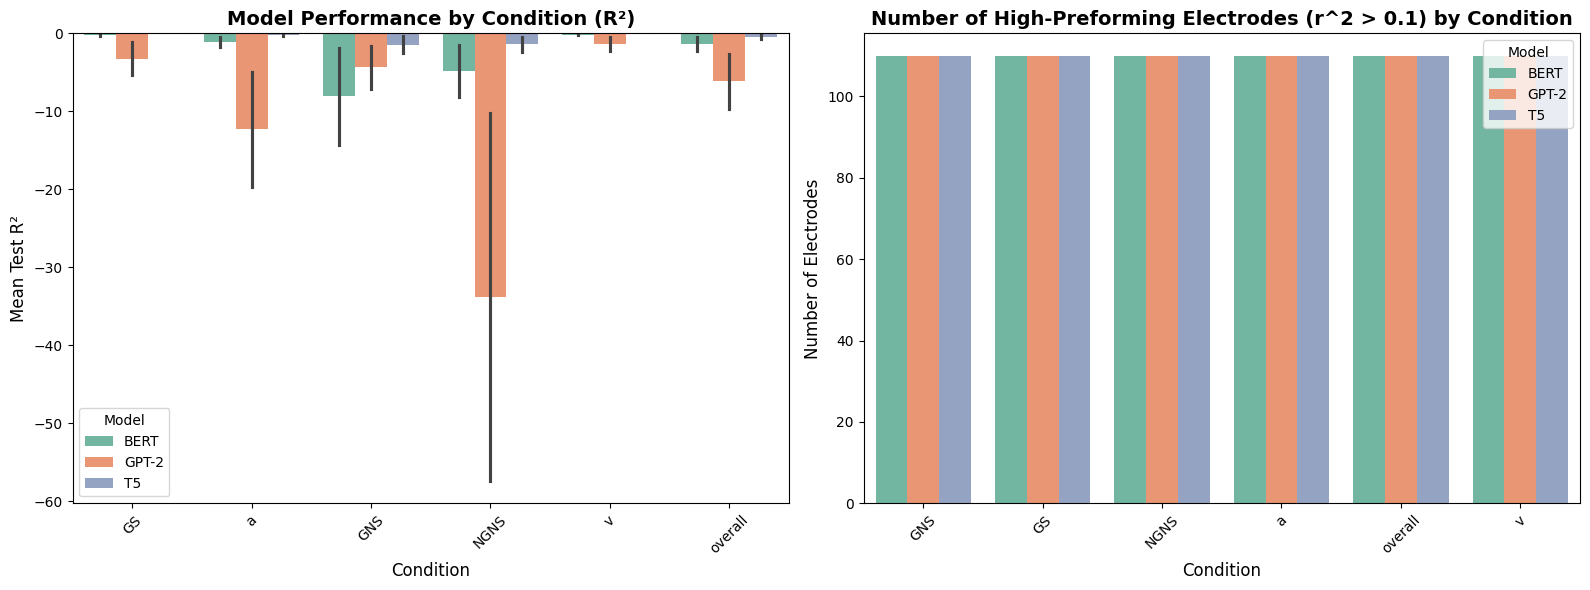


CONDITION-SPECIFIC COMPARISONS (R²)

GS:
  BERT: Mean R² = -0.2589 ± 1.0484 (n=110)
  GPT-2: Mean R² = -3.2360 ± 22.6116 (n=110)
  T5: Mean R² = -0.1100 ± 0.2434 (n=110)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.1869
    BERT vs T5: p=0.2684 ns, d=-0.1965
    GPT-2 vs T5: p=0.0000 ***, d=-0.1964

A:
  BERT: Mean R² = -1.0881 ± 6.6147 (n=110)
  GPT-2: Mean R² = -12.3076 ± 76.9067 (n=110)
  T5: Mean R² = -0.1929 ± 1.1001 (n=110)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.2065
    BERT vs T5: p=0.0000 ***, d=-0.1897
    GPT-2 vs T5: p=0.0000 ***, d=-0.2238

GNS:
  BERT: Mean R² = -8.0873 ± 64.9724 (n=110)
  GPT-2: Mean R² = -4.3675 ± 28.8862 (n=110)
  T5: Mean R² = -1.4812 ± 11.5644 (n=110)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=-0.0743
    BERT vs T5: p=0.0621 ns, d=-0.1422
    GPT-2 vs T5: p=0.0000 ***, d=-0.1318

NGNS:
  BERT: Mean R² = -4.8500 ± 35.0794 (n=110)
  GPT-2: Mean R² = -33.8157 ± 247.0664 (n=110)
  T5: Mean R² = -

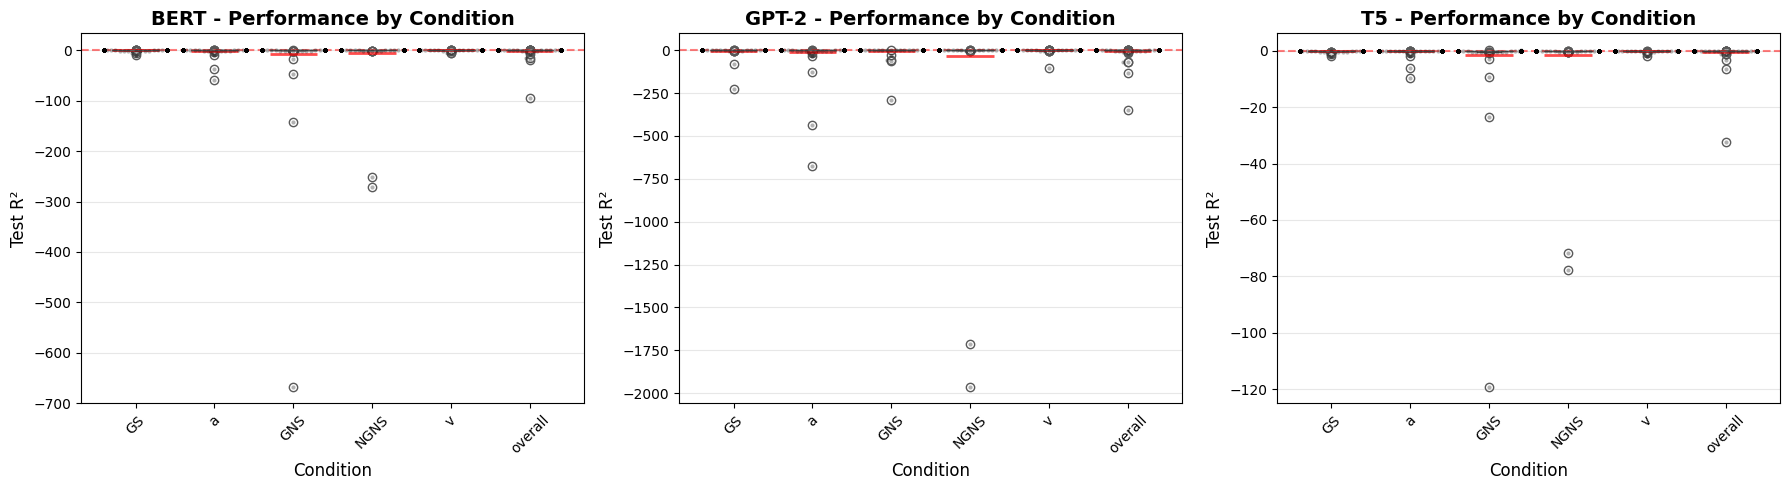


4. R vs R² POWER COMPARISON

R vs R² STATISTICAL POWER COMPARISON

Effect sizes and p-values using R:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R:  p=0.472931, effect size=0.0030, mean diff=0.0006
BERT vs T5:
  R:  p=0.164675, effect size=-0.0515, mean diff=-0.0085
GPT-2 vs T5:
  R:  p=0.004891, effect size=-0.0970, mean diff=-0.0091

Effect sizes and p-values using R²:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R²: p=0.000000, effect size=0.8576, mean diff=7.5773
BERT vs T5:
  R²: p=0.000000, effect size=-0.4182, mean diff=-2.0196
GPT-2 vs T5:
  R²: p=0.000000, effect size=-0.8697, mean diff=-9.5969
RUNNING SUBJECT 8

PREPARING DATA

ORGANIZING DATA BY MODEL

Processing Subject 8:
  DF 0: Model=BERT, Condition=GS, Rows=70
  DF 1: Model=GPT, Condition=GS, Rows=70
  DF 2: Model=T5, Condition=GS, Rows=70
  DF 3: Model=BERT, Condition=a, Rows=70
  DF 4: Model=GPT, Condition=a, R

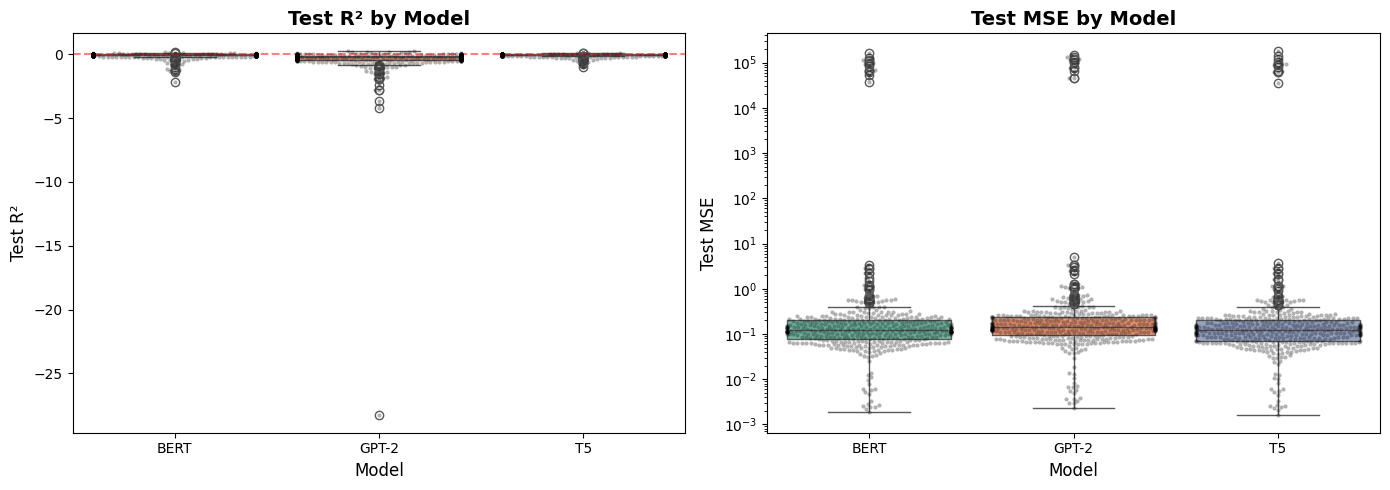

MODEL PERFORMANCE SUMMARY (R²)

BERT:
  Mean Test R²: -0.0871 ± 0.1989
  Median Test R²: -0.0429
  Mean Test MSE: 2551.6344 ± 15908.5952
  # Electrodes: 420
  # High performance (R² > 0.2): 0

GPT-2:
  Mean Test R²: -0.3986 ± 1.4324
  Median Test R²: -0.2184
  Mean Test MSE: 2718.2700 ± 16747.6690
  # Electrodes: 420
  # High performance (R² > 0.2): 3

T5:
  Mean Test R²: -0.0552 ± 0.1062
  Median Test R²: -0.0231
  Mean Test MSE: 2651.8098 ± 16663.4018
  # Electrodes: 420
  # High performance (R² > 0.2): 0

PAIRWISE COMPARISONS (Wilcoxon signed-rank test on R²)
BERT vs GPT-2:
  p-value: 0.0000 ***
  Effect size (r): 0.8524
  Mean difference: 0.3115
BERT vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.2571
  Mean difference: -0.0319
GPT-2 vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.7857
  Mean difference: -0.3434

2. CONDITION-SPECIFIC ANALYSIS


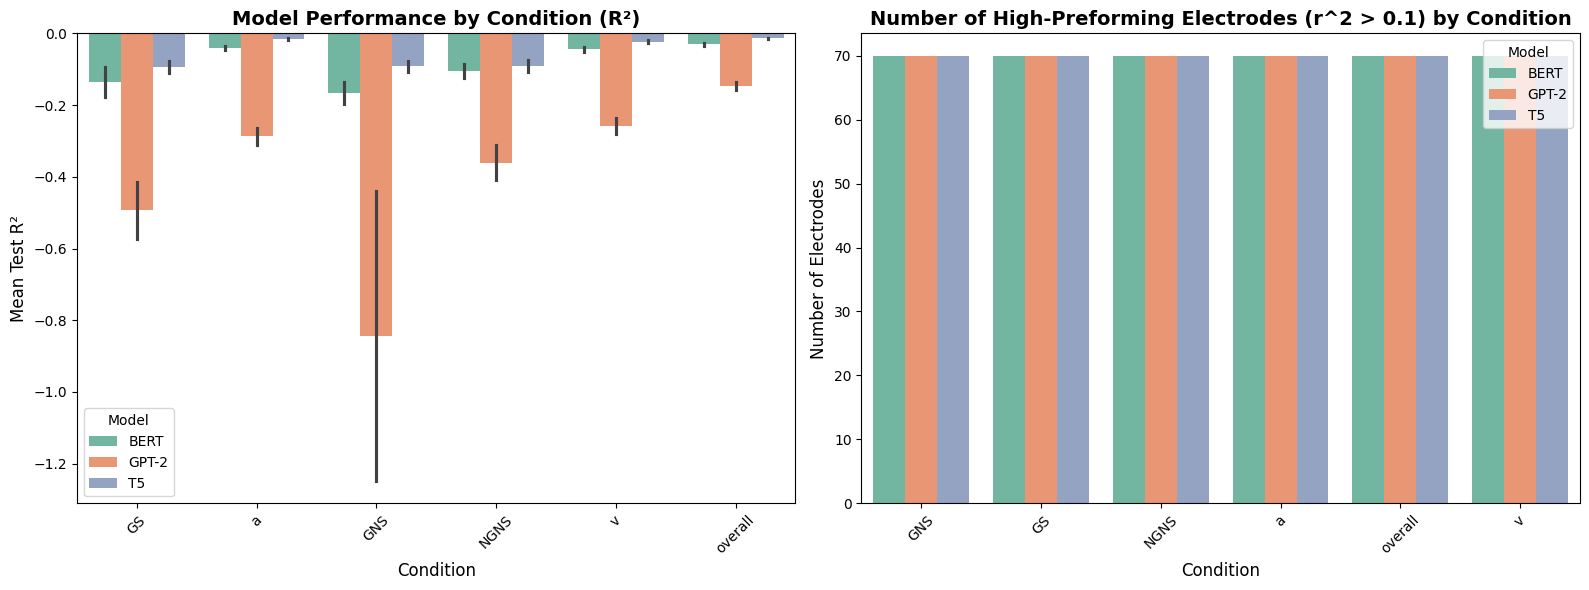


CONDITION-SPECIFIC COMPARISONS (R²)

GS:
  BERT: Mean R² = -0.1354 ± 0.3494 (n=70)
  GPT-2: Mean R² = -0.4934 ± 0.6633 (n=70)
  T5: Mean R² = -0.0938 ± 0.1491 (n=70)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.6803
    BERT vs T5: p=0.6392 ns, d=-0.1556
    GPT-2 vs T5: p=0.0000 ***, d=-0.8372

A:
  BERT: Mean R² = -0.0399 ± 0.0500 (n=70)
  GPT-2: Mean R² = -0.2876 ± 0.1942 (n=70)
  T5: Mean R² = -0.0170 ± 0.0242 (n=70)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=1.7597
    BERT vs T5: p=0.0003 ***, d=-0.5868
    GPT-2 vs T5: p=0.0000 ***, d=-1.9699

GNS:
  BERT: Mean R² = -0.1661 ± 0.2610 (n=70)
  GPT-2: Mean R² = -0.8433 ± 3.3861 (n=70)
  T5: Mean R² = -0.0920 ± 0.1243 (n=70)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0004 ***, d=0.2841
    BERT vs T5: p=0.1441 ns, d=-0.3649
    GPT-2 vs T5: p=0.0000 ***, d=-0.3159

NGNS:
  BERT: Mean R² = -0.1059 ± 0.1648 (n=70)
  GPT-2: Mean R² = -0.3613 ± 0.4081 (n=70)
  T5: Mean R² = -0.0903 ± 0.1431 (n=70)

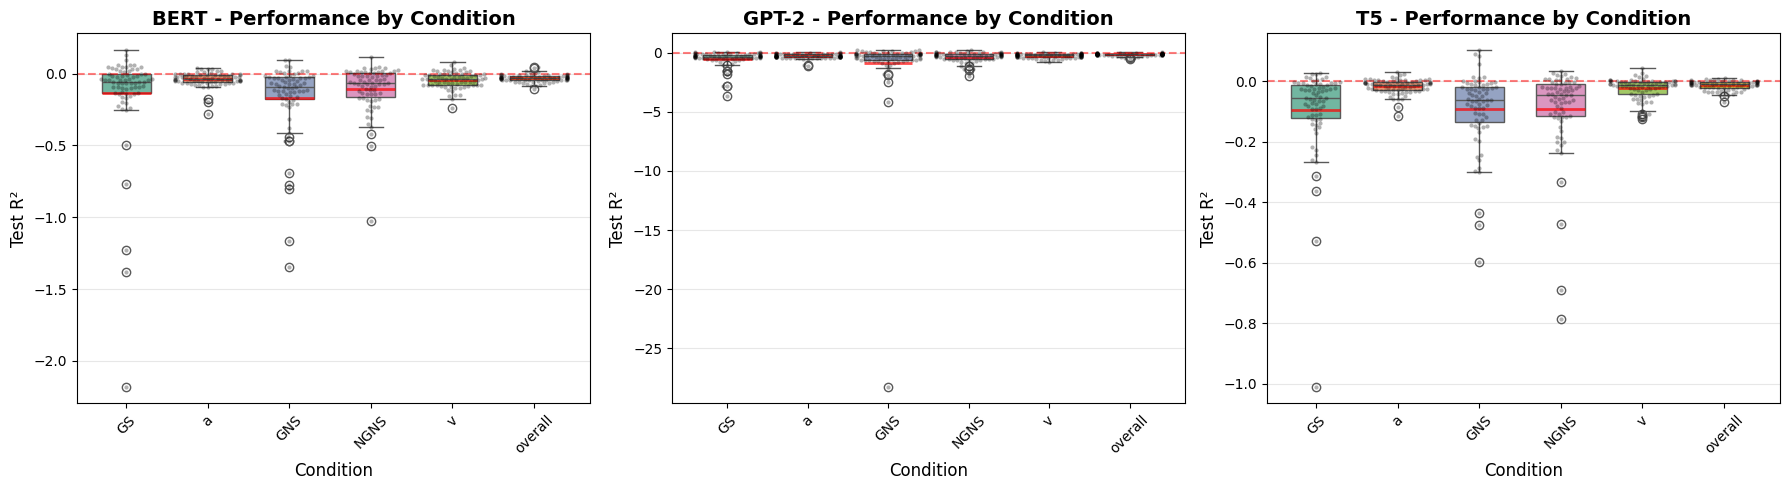


4. R vs R² POWER COMPARISON

R vs R² STATISTICAL POWER COMPARISON

Effect sizes and p-values using R:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R:  p=0.838917, effect size=0.0667, mean diff=-0.0043
BERT vs T5:
  R:  p=0.256751, effect size=-0.0095, mean diff=-0.0093
GPT-2 vs T5:
  R:  p=0.346361, effect size=-0.0571, mean diff=-0.0049

Effect sizes and p-values using R²:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R²: p=0.000000, effect size=0.8524, mean diff=0.3115
BERT vs T5:
  R²: p=0.000000, effect size=-0.2571, mean diff=-0.0319
GPT-2 vs T5:
  R²: p=0.000000, effect size=-0.7857, mean diff=-0.3434
RUNNING SUBJECT 12

PREPARING DATA

ORGANIZING DATA BY MODEL

Processing Subject 12:
  DF 0: Model=BERT, Condition=GS, Rows=78
  DF 1: Model=GPT, Condition=GS, Rows=78
  DF 2: Model=T5, Condition=GS, Rows=78
  DF 3: Model=BERT, Condition=a, Rows=78
  DF 4: Model=GPT, Condition=a

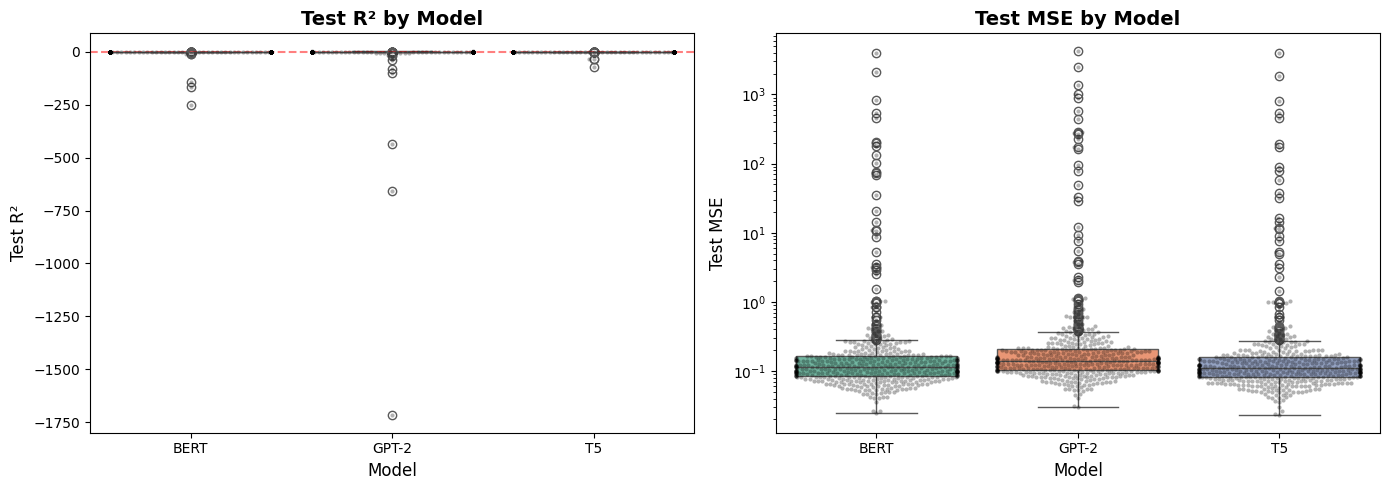

MODEL PERFORMANCE SUMMARY (R²)

BERT:
  Mean Test R²: -1.3589 ± 15.3536
  Median Test R²: -0.0463
  Mean Test MSE: 19.6639 ± 216.4358
  # Electrodes: 468
  # High performance (R² > 0.2): 0

GPT-2:
  Mean Test R²: -7.0285 ± 87.2495
  Median Test R²: -0.2830
  Mean Test MSE: 27.3036 ± 244.4926
  # Electrodes: 468
  # High performance (R² > 0.2): 3

T5:
  Mean Test R²: -0.3573 ± 3.9817
  Median Test R²: -0.0212
  Mean Test MSE: 18.1553 ± 210.4636
  # Electrodes: 468
  # High performance (R² > 0.2): 0

PAIRWISE COMPARISONS (Wilcoxon signed-rank test on R²)
BERT vs GPT-2:
  p-value: 0.0000 ***
  Effect size (r): 0.8547
  Mean difference: 5.6695
BERT vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.3675
  Mean difference: -1.0017
GPT-2 vs T5:
  p-value: 0.0000 ***
  Effect size (r): -0.8504
  Mean difference: -6.6712

2. CONDITION-SPECIFIC ANALYSIS


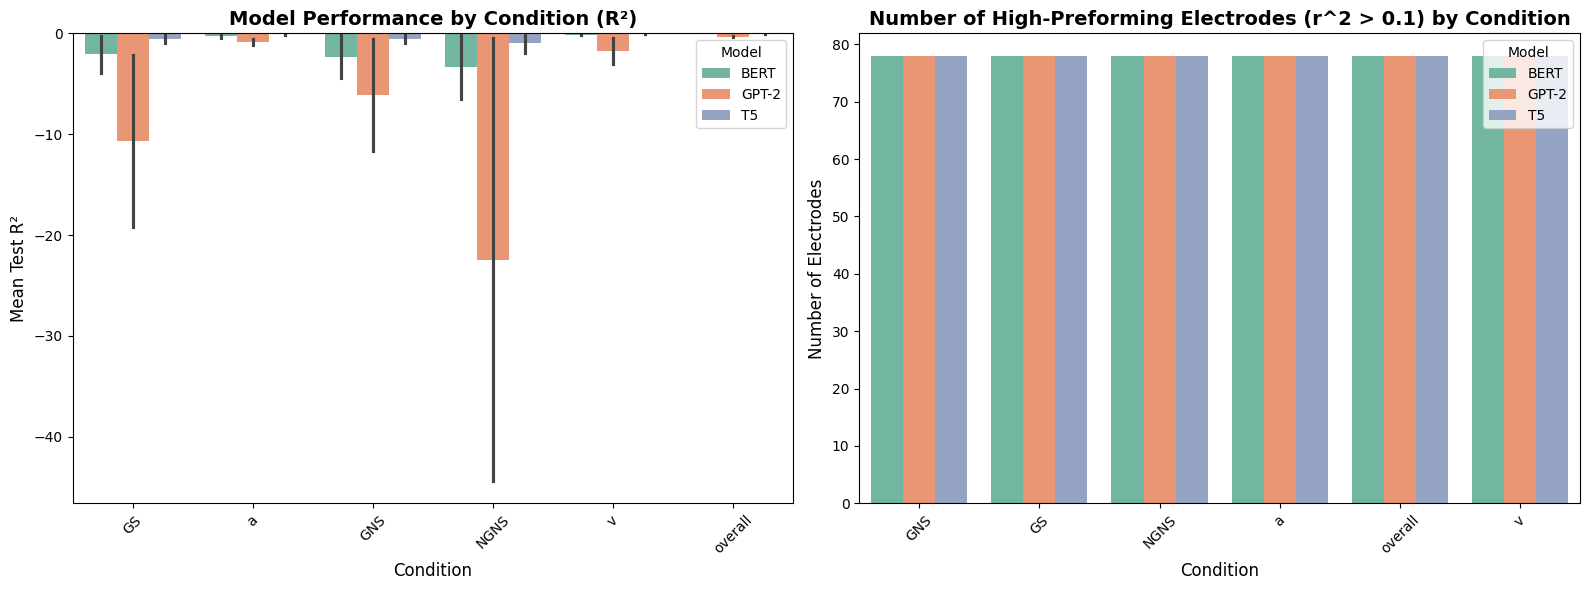


CONDITION-SPECIFIC COMPARISONS (R²)

GS:
  BERT: Mean R² = -2.0873 ± 16.0435 (n=78)
  GPT-2: Mean R² = -10.6666 ± 75.1991 (n=78)
  T5: Mean R² = -0.5260 ± 3.7395 (n=78)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.1588
    BERT vs T5: p=0.7781 ns, d=-0.1349
    GPT-2 vs T5: p=0.0000 ***, d=-0.1917

A:
  BERT: Mean R² = -0.2505 ± 1.5068 (n=78)
  GPT-2: Mean R² = -0.8849 ± 2.4213 (n=78)
  T5: Mean R² = -0.0702 ± 0.4530 (n=78)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.3166
    BERT vs T5: p=0.0000 ***, d=-0.1631
    GPT-2 vs T5: p=0.0000 ***, d=-0.4708

GNS:
  BERT: Mean R² = -2.3064 ± 18.7750 (n=78)
  GPT-2: Mean R² = -6.0918 ± 49.1828 (n=78)
  T5: Mean R² = -0.5210 ± 3.8924 (n=78)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.0000 ***, d=0.1023
    BERT vs T5: p=0.0367 *, d=-0.1325
    GPT-2 vs T5: p=0.0000 ***, d=-0.1607

NGNS:
  BERT: Mean R² = -3.3413 ± 28.4110 (n=78)
  GPT-2: Mean R² = -22.4275 ± 193.8856 (n=78)
  T5: Mean R² = -0.9867 ± 8.126

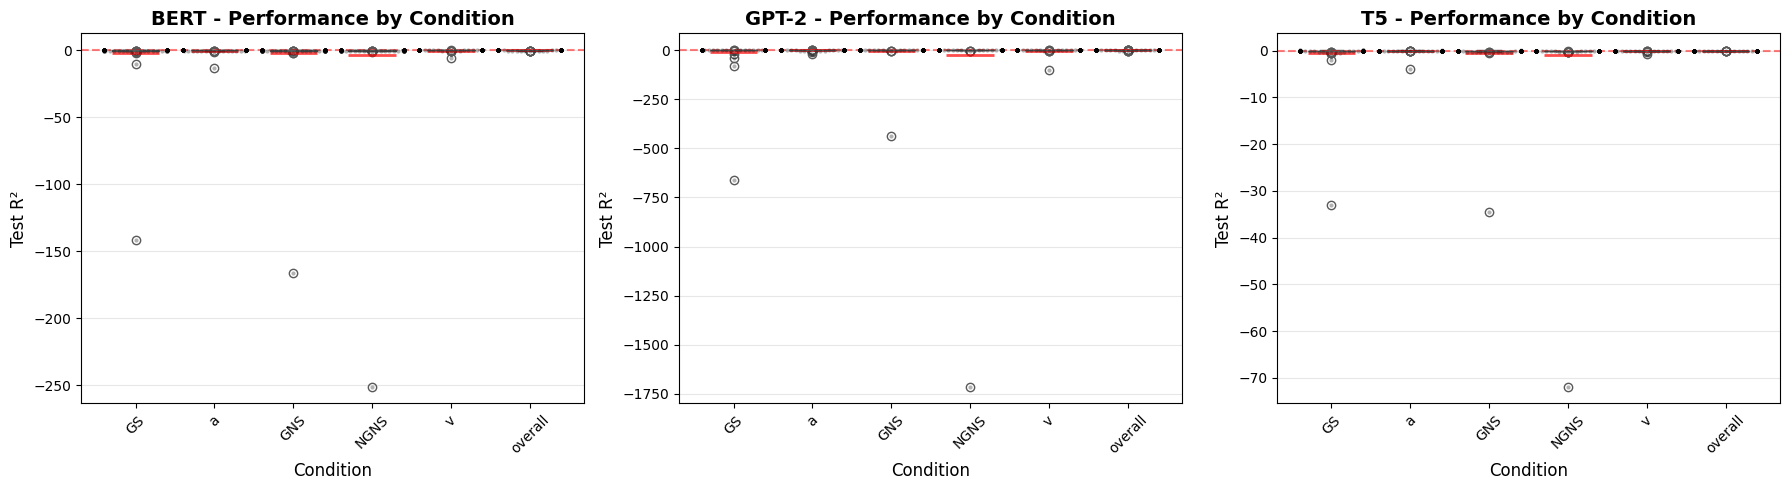


4. R vs R² POWER COMPARISON

R vs R² STATISTICAL POWER COMPARISON

Effect sizes and p-values using R:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R:  p=0.452948, effect size=0.0256, mean diff=0.0023
BERT vs T5:
  R:  p=0.703791, effect size=0.0470, mean diff=0.0008
GPT-2 vs T5:
  R:  p=0.355462, effect size=-0.0214, mean diff=-0.0015

Effect sizes and p-values using R²:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R²: p=0.000000, effect size=0.8547, mean diff=5.6695
BERT vs T5:
  R²: p=0.000000, effect size=-0.3675, mean diff=-1.0017
GPT-2 vs T5:
  R²: p=0.000000, effect size=-0.8504, mean diff=-6.6712


In [43]:
print("\n" + "="*80)
print("ANALYSIS ON ALL ELECTRODES")
print("="*80)
#Cohens d effect size: ~0.2 (small), ~0.5 (medium), and ~0.8 (large
#A negative Cohen's d means the mean of the first group (Group 1) is lower than the mean of the second group (Group 2)
for sub in subjects_run:
    print(f"RUNNING SUBJECT {sub}")
    mini_dict = {sub: all_elecs[sub]}
    model_data_filtered, condition_data_filtered = run_comprehensive_analysis(mini_dict)

## Imposing Tolerance of R^2 value To filer down electrodes

In [ ]:
further_filter_elecs = collections.defaultdict(list)
for sub, data in saved_elecs.items():
    for elec in data:
        train_R_2 = float(elec["train_R_2"].iloc[0])
        test_R_2 = float(elec["test_R_2"].iloc[0])
        
        if check_r2_tolerance(train_R_2, test_R_2, ):
            further_filter_elecs[sub].append(elec)

In [ ]:
counter = 0
for sub,data in further_filter_elecs.items():
    print(f"SUBJECT DATA S{sub}")
    for elec in data:
        print(elec.columns)
        counter+=1
        print(elec)
print(f"{counter} Electrodes Remaining")

SUBJECT DATA S1
Index(['electrode', 'best_alpha', 'train_MSE', 'test_MSE', 'train_R', 'test_R',
       'train_R_2', 'test_R_2', 'subjectNum', 'elecNum', 'isRejectManual',
       'parcLabel', 'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL',
       'isWM', 'unknown_wmParc', 'groupLabels', 'isLeft', 'groupAvgCoords',
       'Elec_index', 'condition', 'model'],
      dtype='object')
       electrode  best_alpha  train_MSE  test_MSE   train_R    test_R  \
12  electrode_12       100.0   0.094144  0.048984  0.449937  0.361191   

    train_R_2  test_R_2  subjectNum  elecNum  ...  isRejectFSL_2wm  \
12    0.12378    0.1054           1       13  ...                0   

   isRejectFSL isWM unknown_wmParc   groupLabels  isLeft  \
12           0    1              0  LAI13 s1 e13       1   

                                       groupAvgCoords  Elec_index condition  \
12  [-40.86806661504363, 29.39356787918851, 23.507...          12        GS   

    model  
12   BERT  

[1 rows x 24 column

## Graphing


GENERATING VISUALIZATIONS

VISUALIZING SUBJECT 1

1. Generating top electrodes summary...


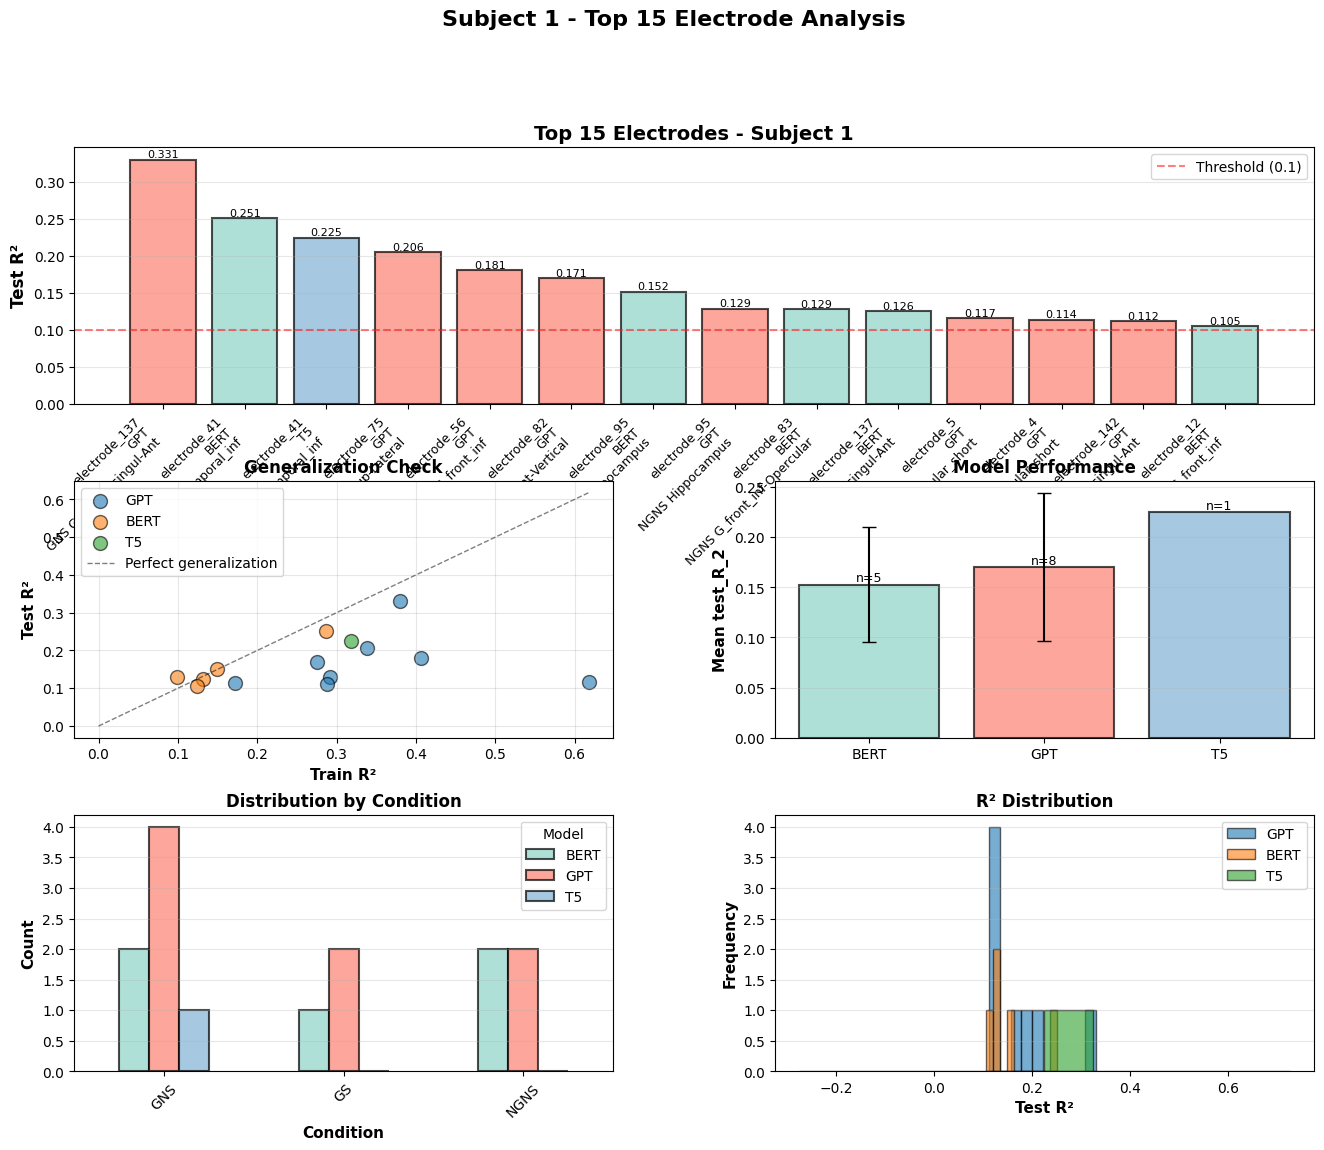


TOP 15 ELECTRODES SUMMARY - SUBJECT 1

Mean Test R²: 0.1677 ± 0.0656
Range: 0.1054 - 0.3307

Model Distribution:
model
GPT     8
BERT    5
T5      1
Name: count, dtype: int64

Condition Distribution:
condition
GNS     7
NGNS    4
GS      3
Name: count, dtype: int64

2. Generating power visualizations for top 5 electrodes...
   Plotting electrode electrode_137 (index 137)...


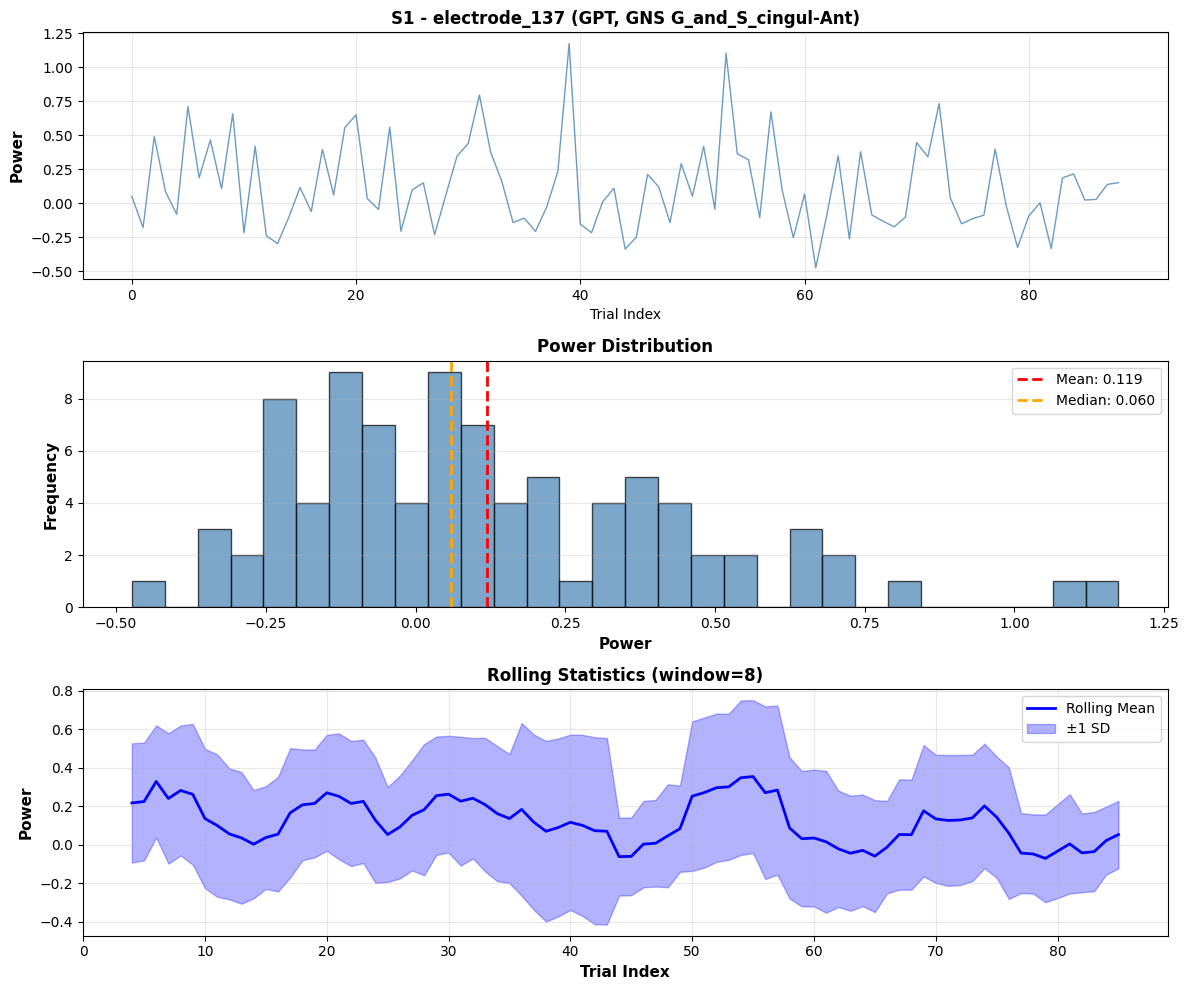


Electrode 137 - Power Statistics
Mean:   0.1195
Median: 0.0597
Std:    0.3217
Min:    -0.4737
Max:    1.1738
Range:  1.6475
   Plotting electrode electrode_41 (index 41)...


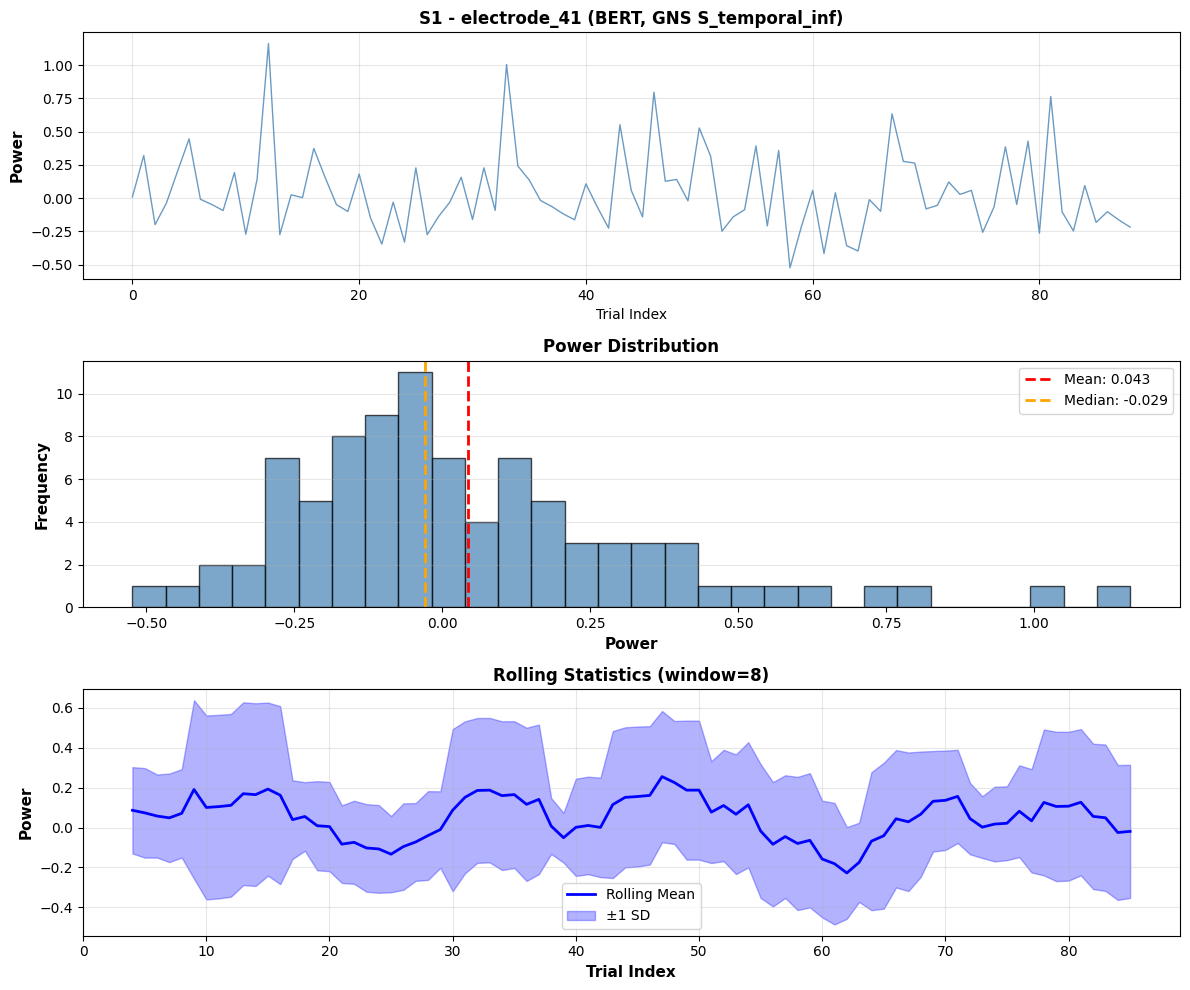


Electrode 41 - Power Statistics
Mean:   0.0432
Median: -0.0295
Std:    0.3022
Min:    -0.5235
Max:    1.1626
Range:  1.6862
   Plotting electrode electrode_41 (index 41)...


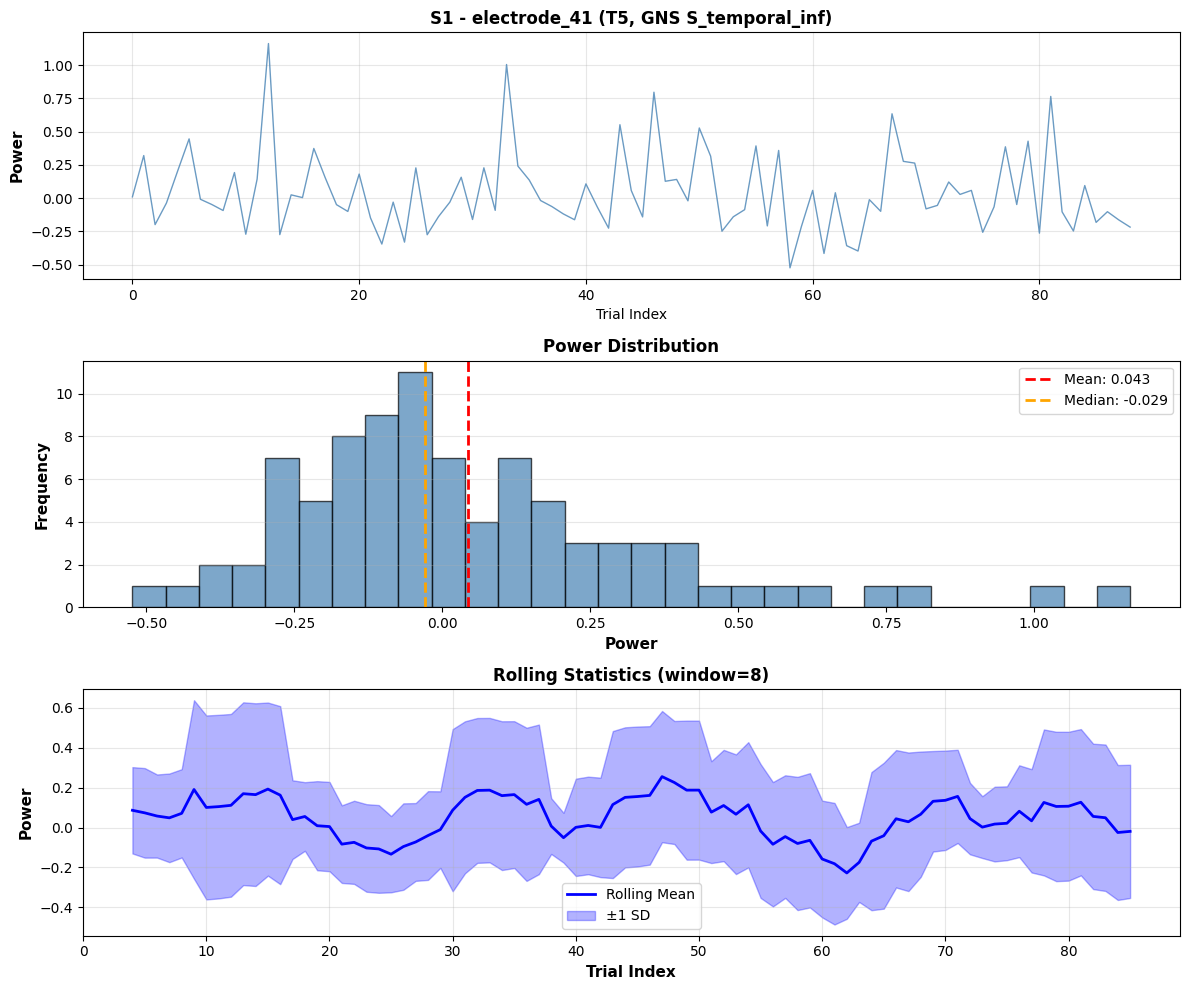


Electrode 41 - Power Statistics
Mean:   0.0432
Median: -0.0295
Std:    0.3022
Min:    -0.5235
Max:    1.1626
Range:  1.6862
   Plotting electrode electrode_75 (index 75)...


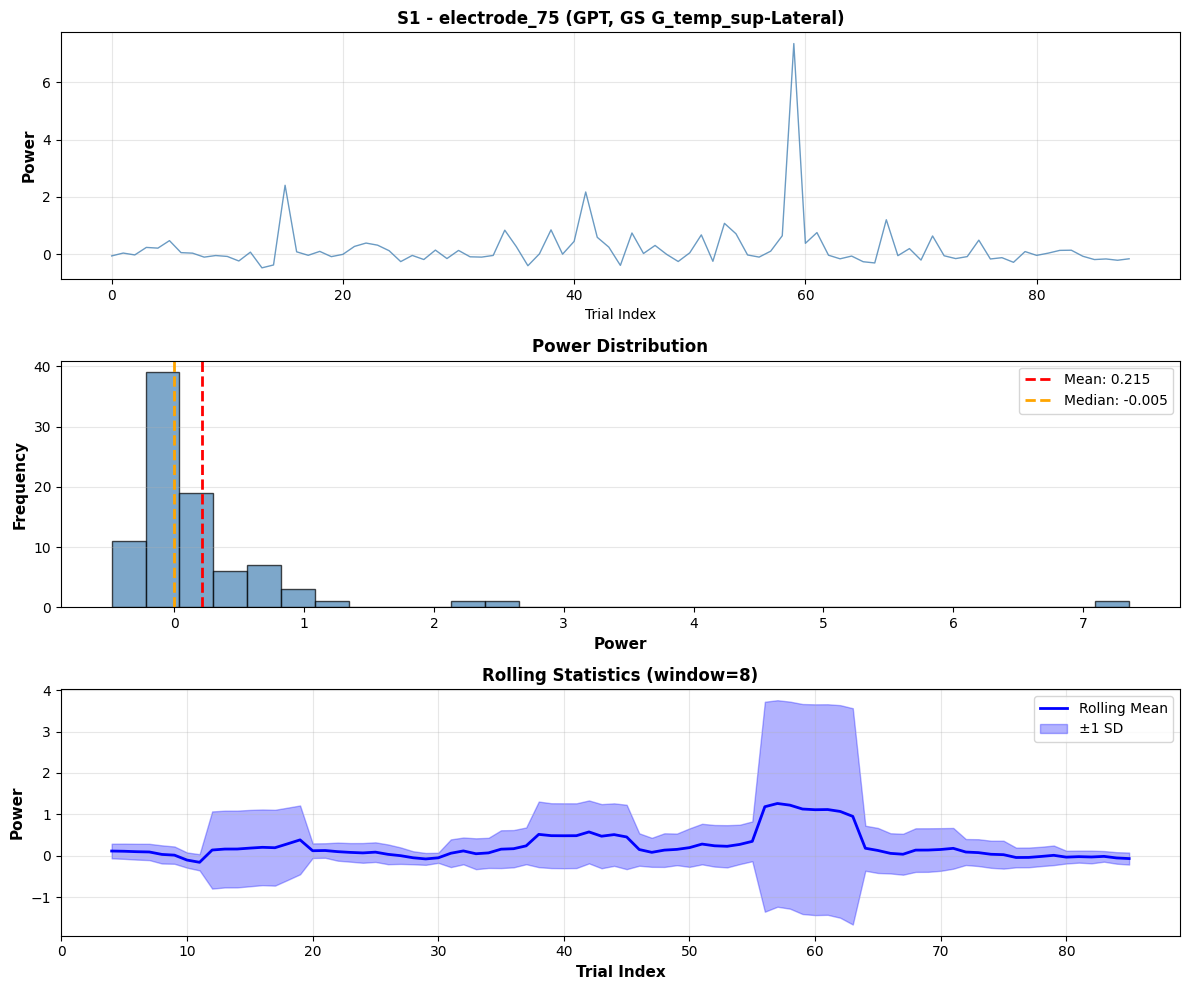


Electrode 75 - Power Statistics
Mean:   0.2149
Median: -0.0053
Std:    0.8926
Min:    -0.4826
Max:    7.3559
Range:  7.8385
   Plotting electrode electrode_56 (index 56)...


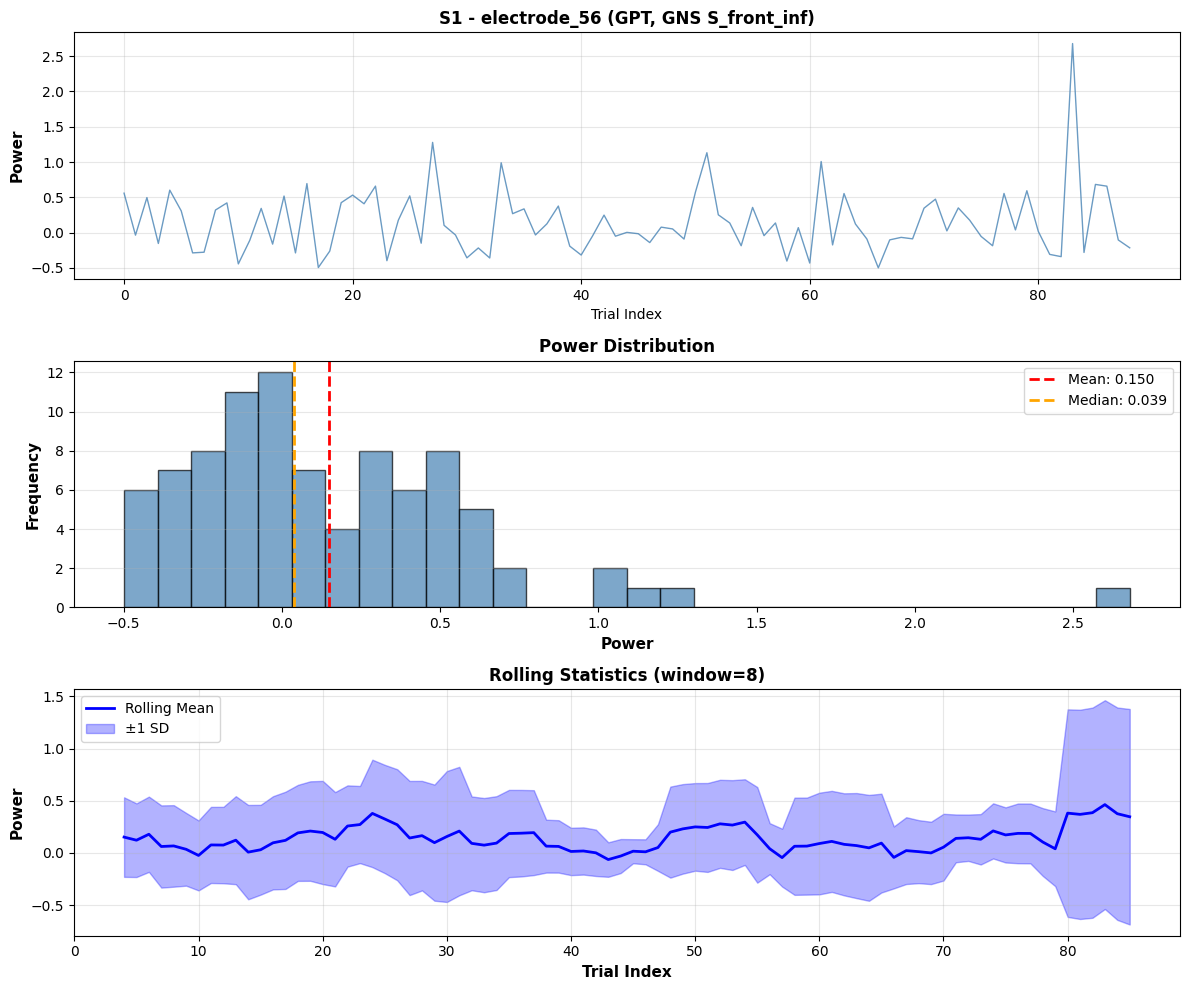


Electrode 56 - Power Statistics
Mean:   0.1497
Median: 0.0387
Std:    0.4685
Min:    -0.4983
Max:    2.6781
Range:  3.1764

3. Prediction plots require pipeline modification (skipping for now)
   See add_predictions_to_pipeline() for details

VISUALIZING SUBJECT 8

1. Generating top electrodes summary...


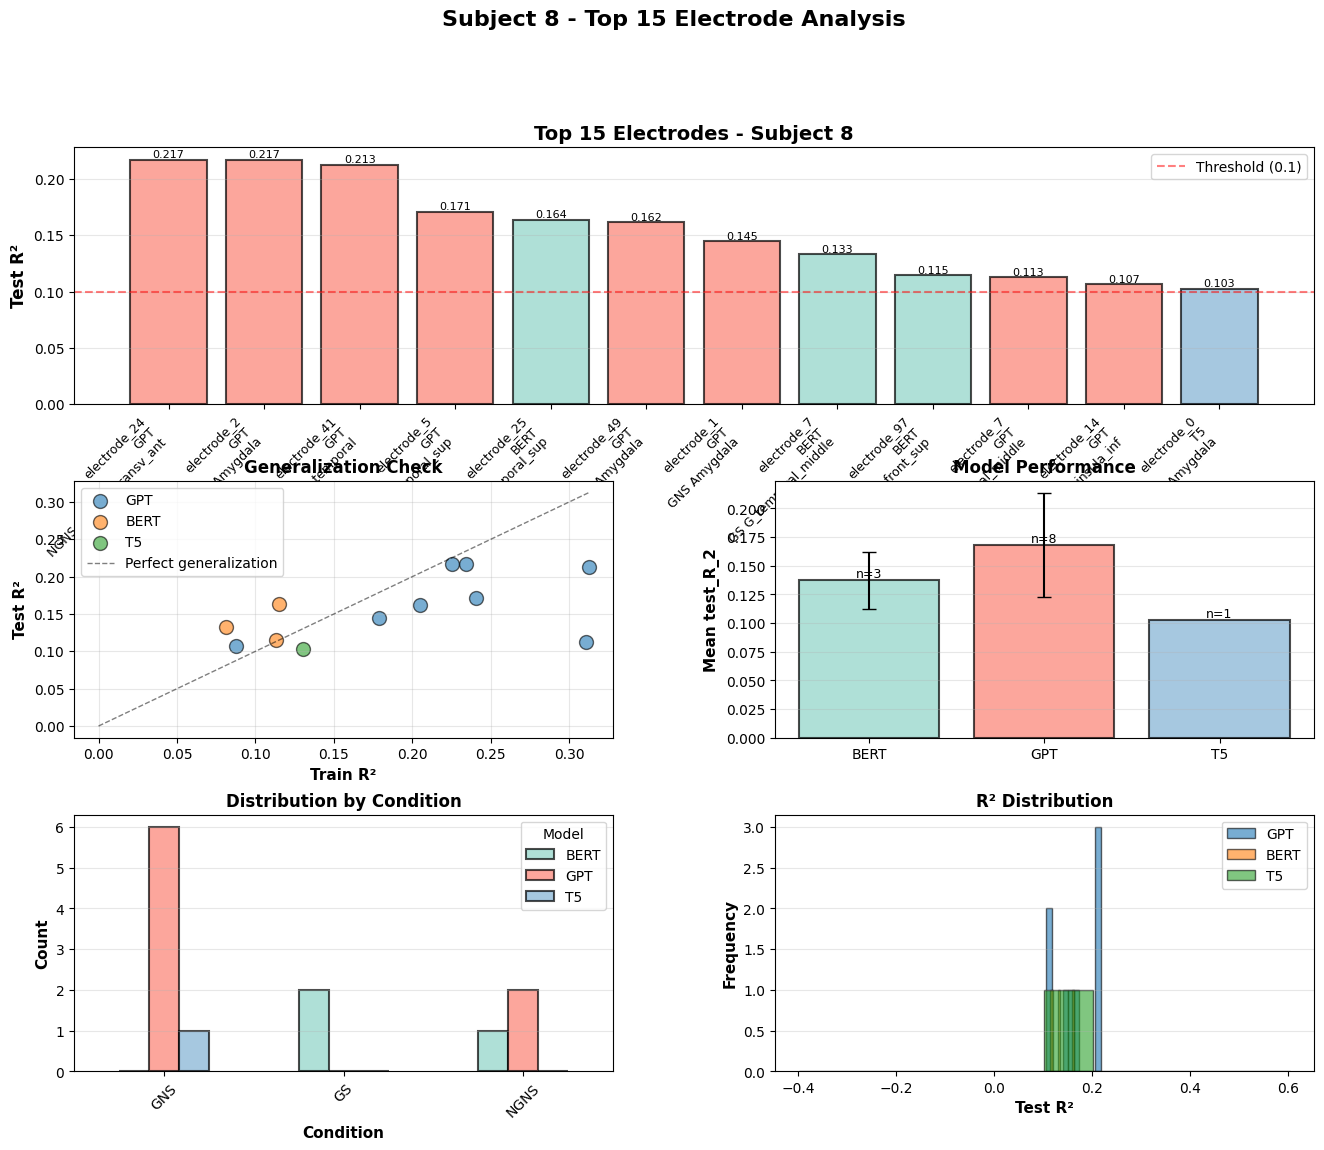


TOP 15 ELECTRODES SUMMARY - SUBJECT 8

Mean Test R²: 0.1549 ± 0.0433
Range: 0.1026 - 0.2174

Model Distribution:
model
GPT     8
BERT    3
T5      1
Name: count, dtype: int64

Condition Distribution:
condition
GNS     7
NGNS    3
GS      2
Name: count, dtype: int64

2. Generating power visualizations for top 5 electrodes...
   Plotting electrode electrode_24 (index 24)...


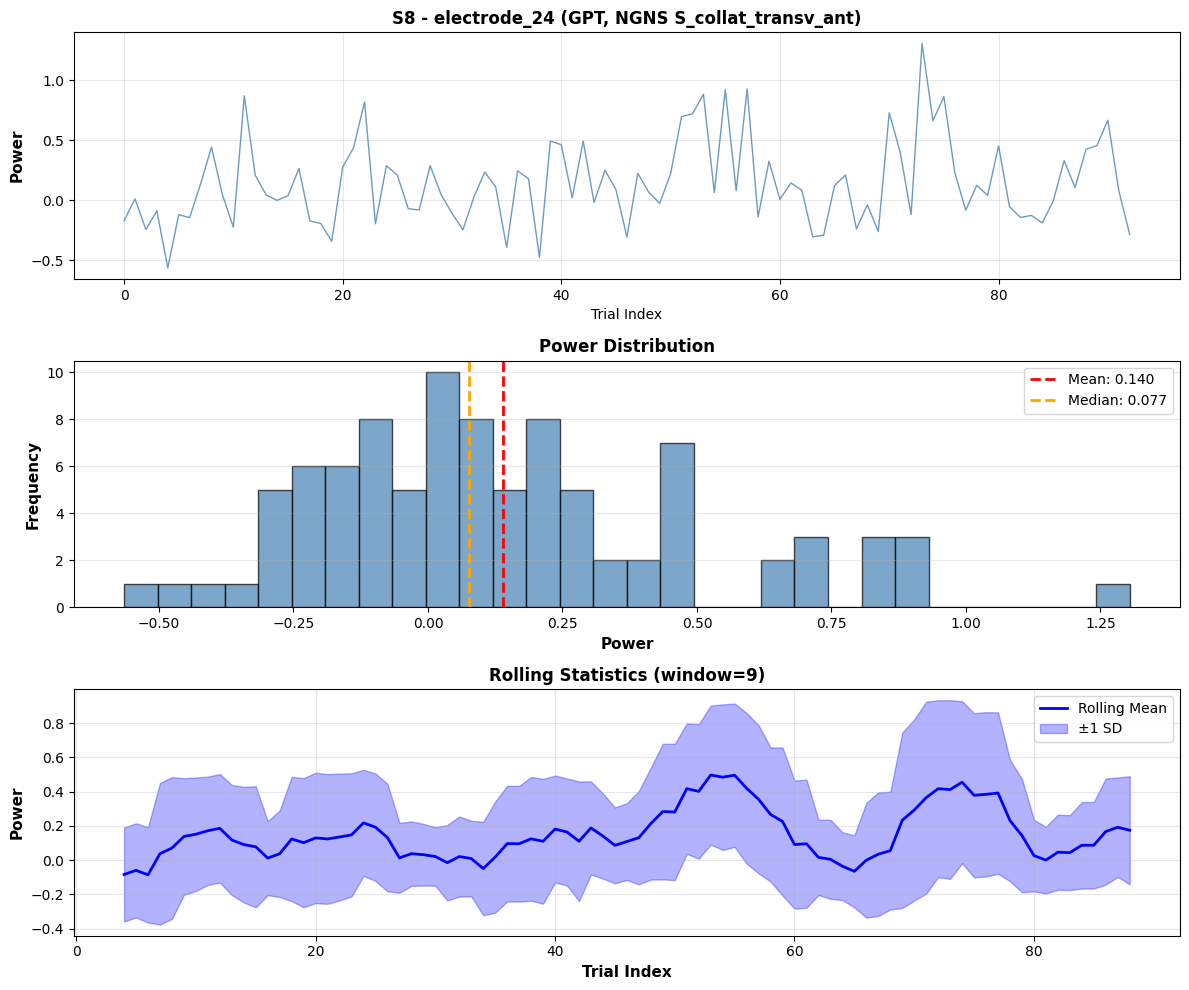


Electrode 24 - Power Statistics
Mean:   0.1397
Median: 0.0769
Std:    0.3551
Min:    -0.5649
Max:    1.3043
Range:  1.8692
   Plotting electrode electrode_2 (index 2)...


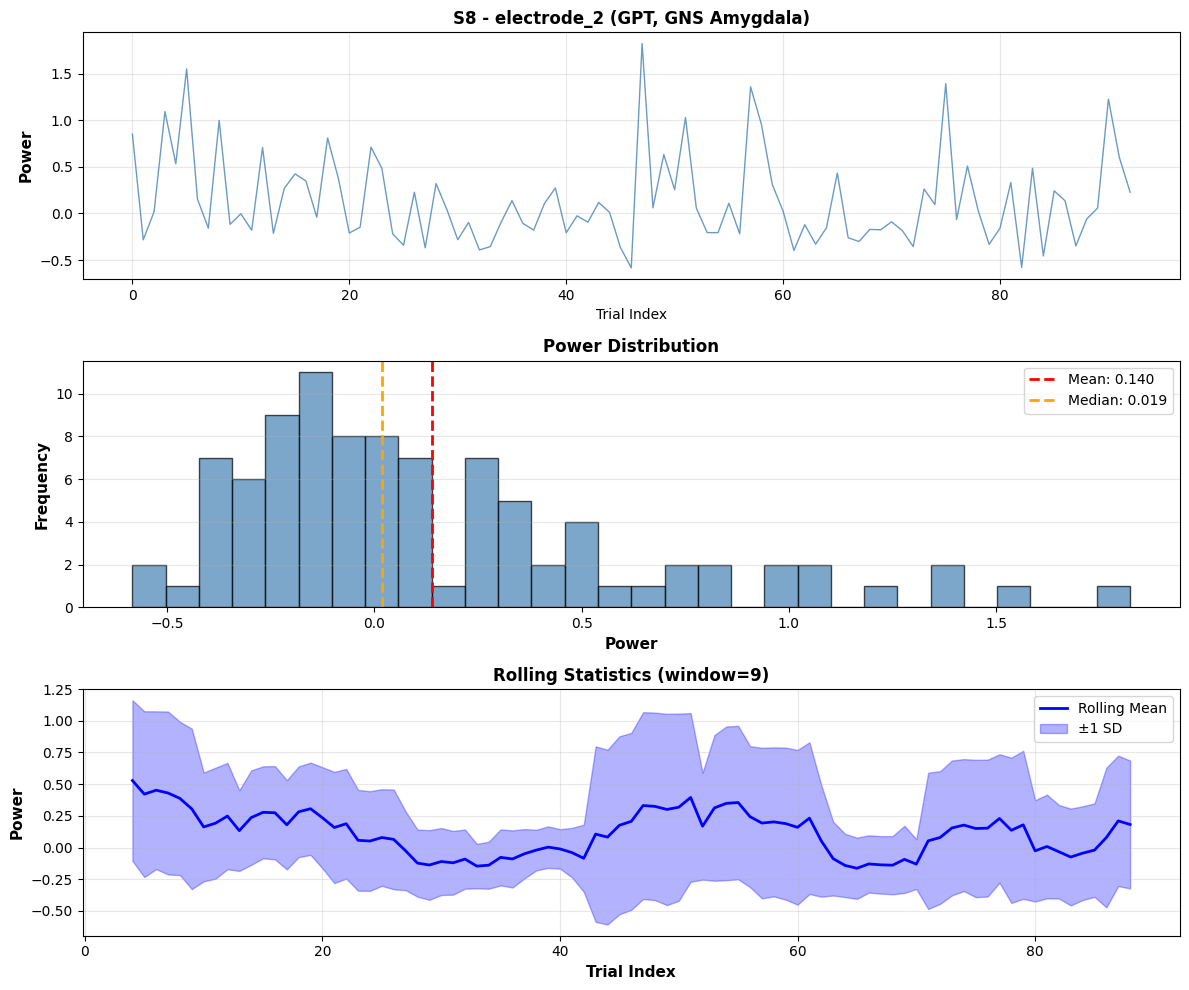


Electrode 2 - Power Statistics
Mean:   0.1398
Median: 0.0190
Std:    0.4883
Min:    -0.5833
Max:    1.8228
Range:  2.4061
   Plotting electrode electrode_41 (index 41)...


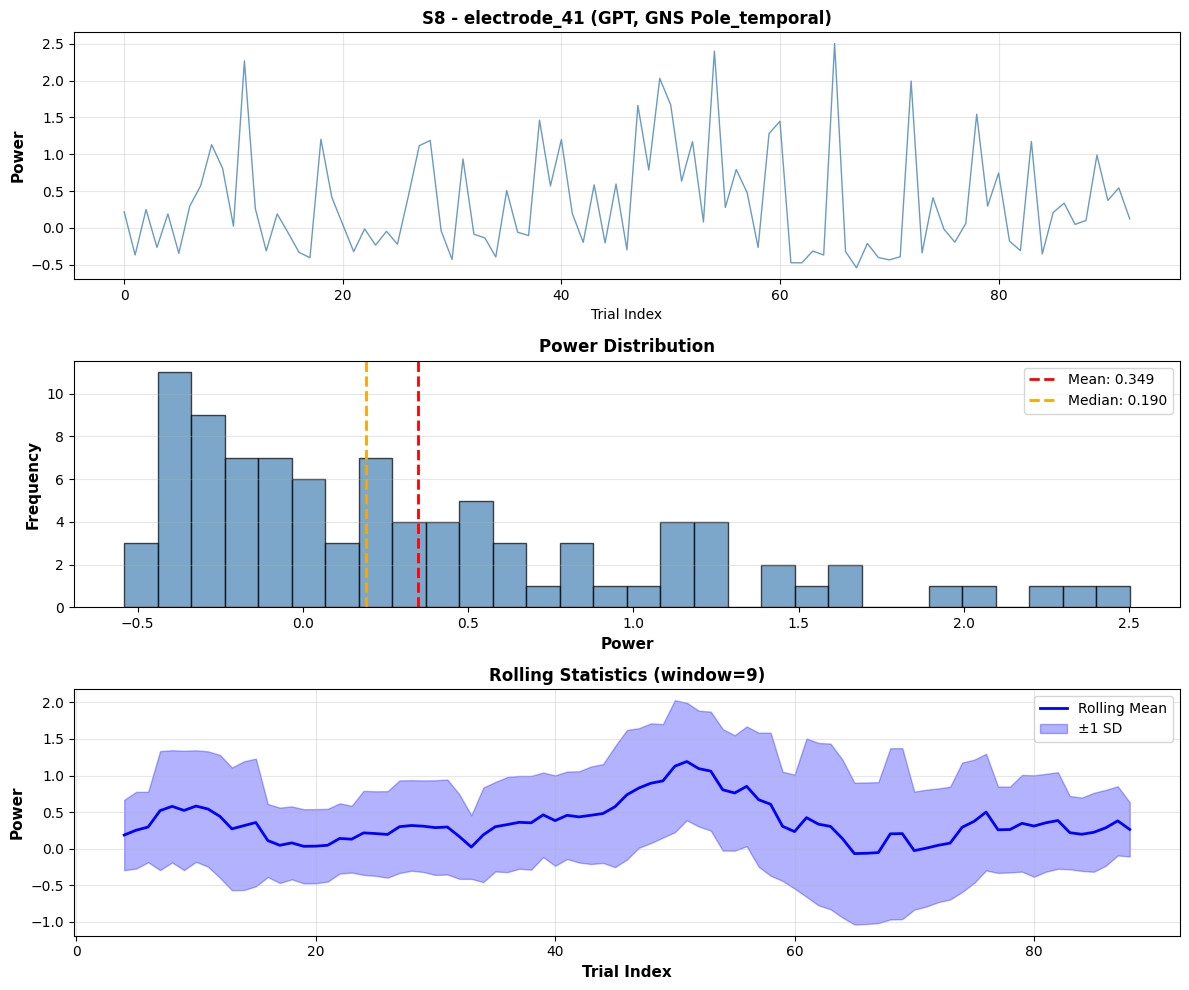


Electrode 41 - Power Statistics
Mean:   0.3486
Median: 0.1900
Std:    0.7270
Min:    -0.5409
Max:    2.5021
Range:  3.0430
   Plotting electrode electrode_5 (index 5)...


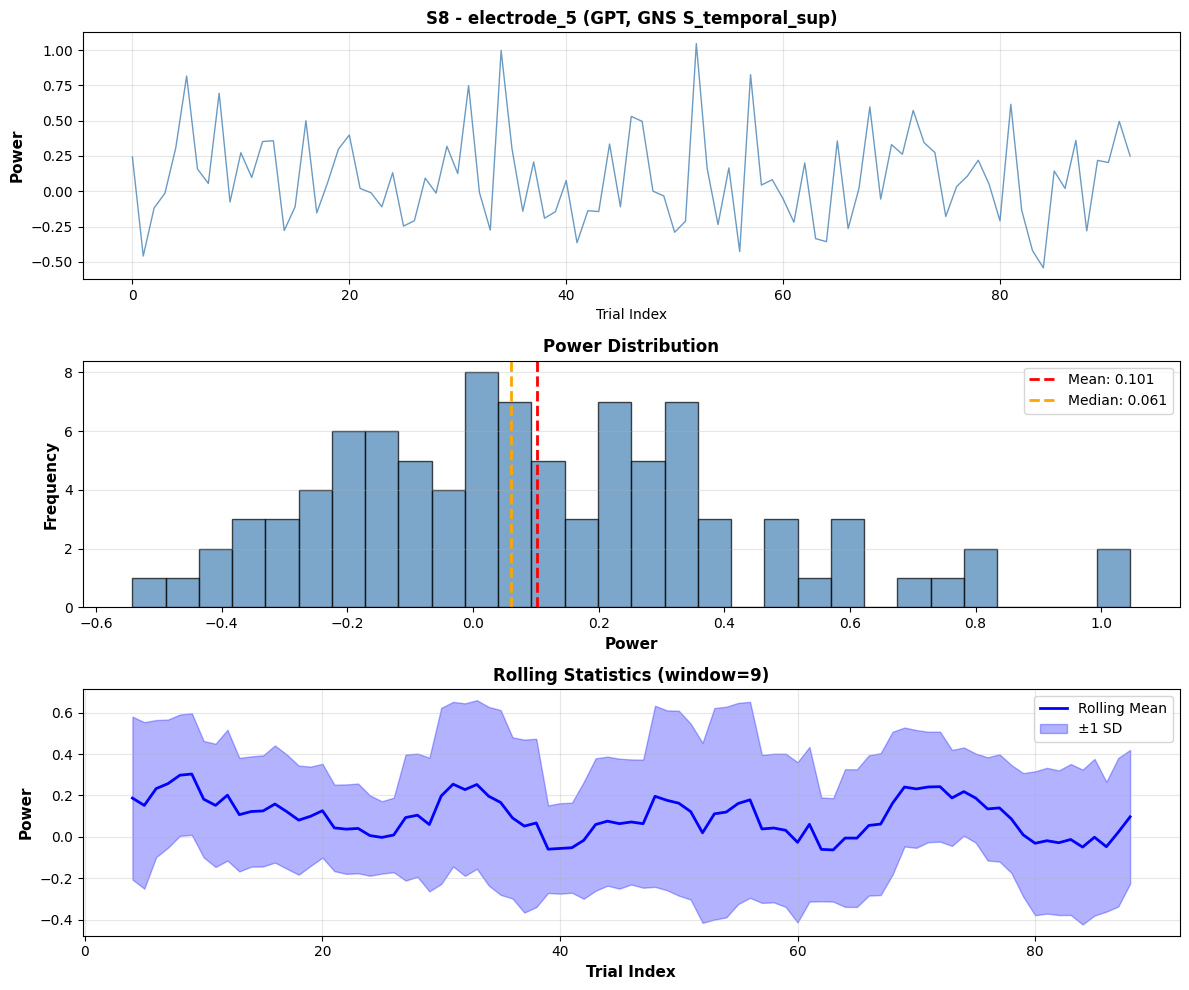


Electrode 5 - Power Statistics
Mean:   0.1015
Median: 0.0611
Std:    0.3264
Min:    -0.5421
Max:    1.0460
Range:  1.5881
   Plotting electrode electrode_25 (index 25)...


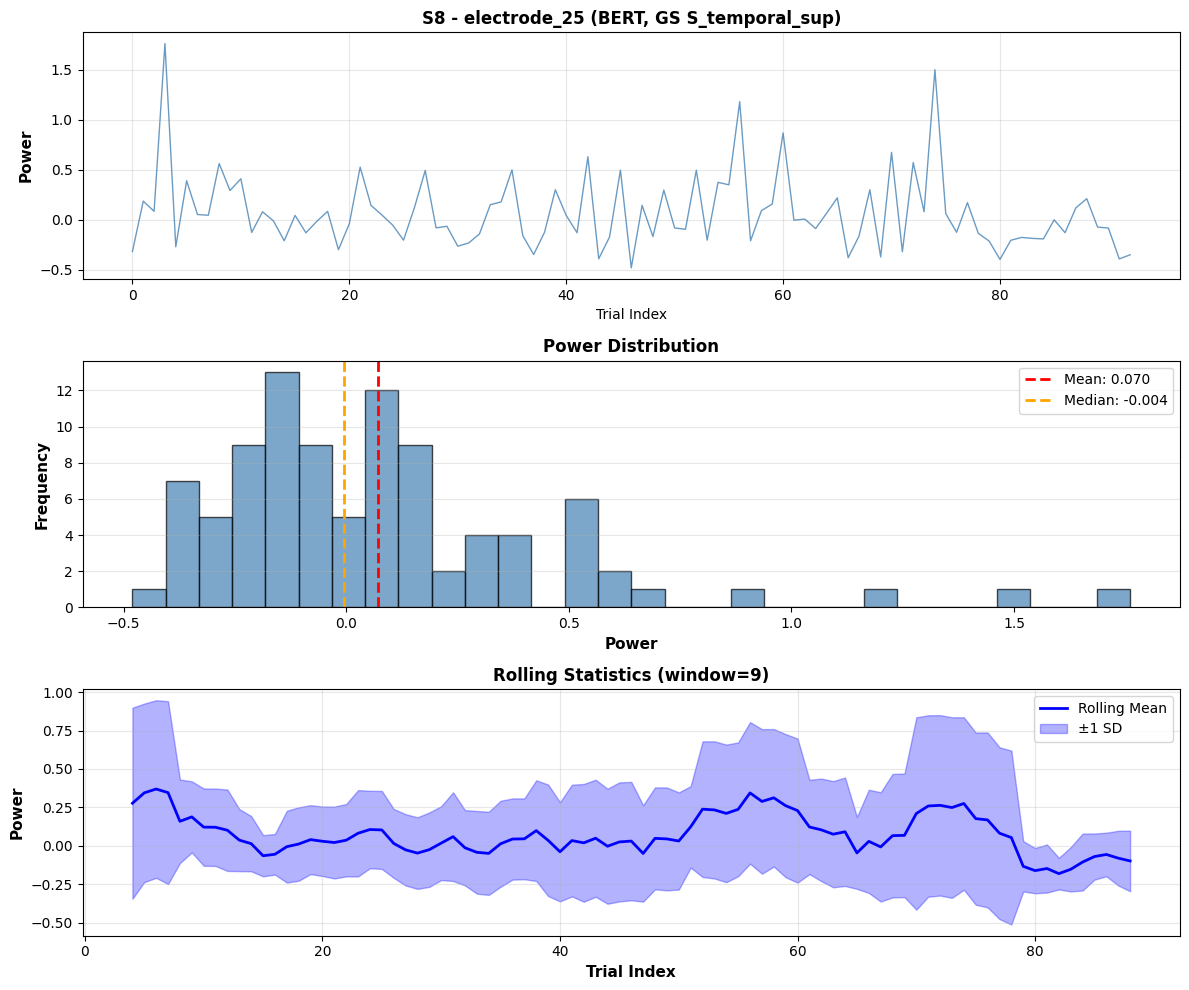


Electrode 25 - Power Statistics
Mean:   0.0702
Median: -0.0041
Std:    0.3803
Min:    -0.4806
Max:    1.7609
Range:  2.2414

3. Prediction plots require pipeline modification (skipping for now)
   See add_predictions_to_pipeline() for details

VISUALIZING SUBJECT 12

1. Generating top electrodes summary...


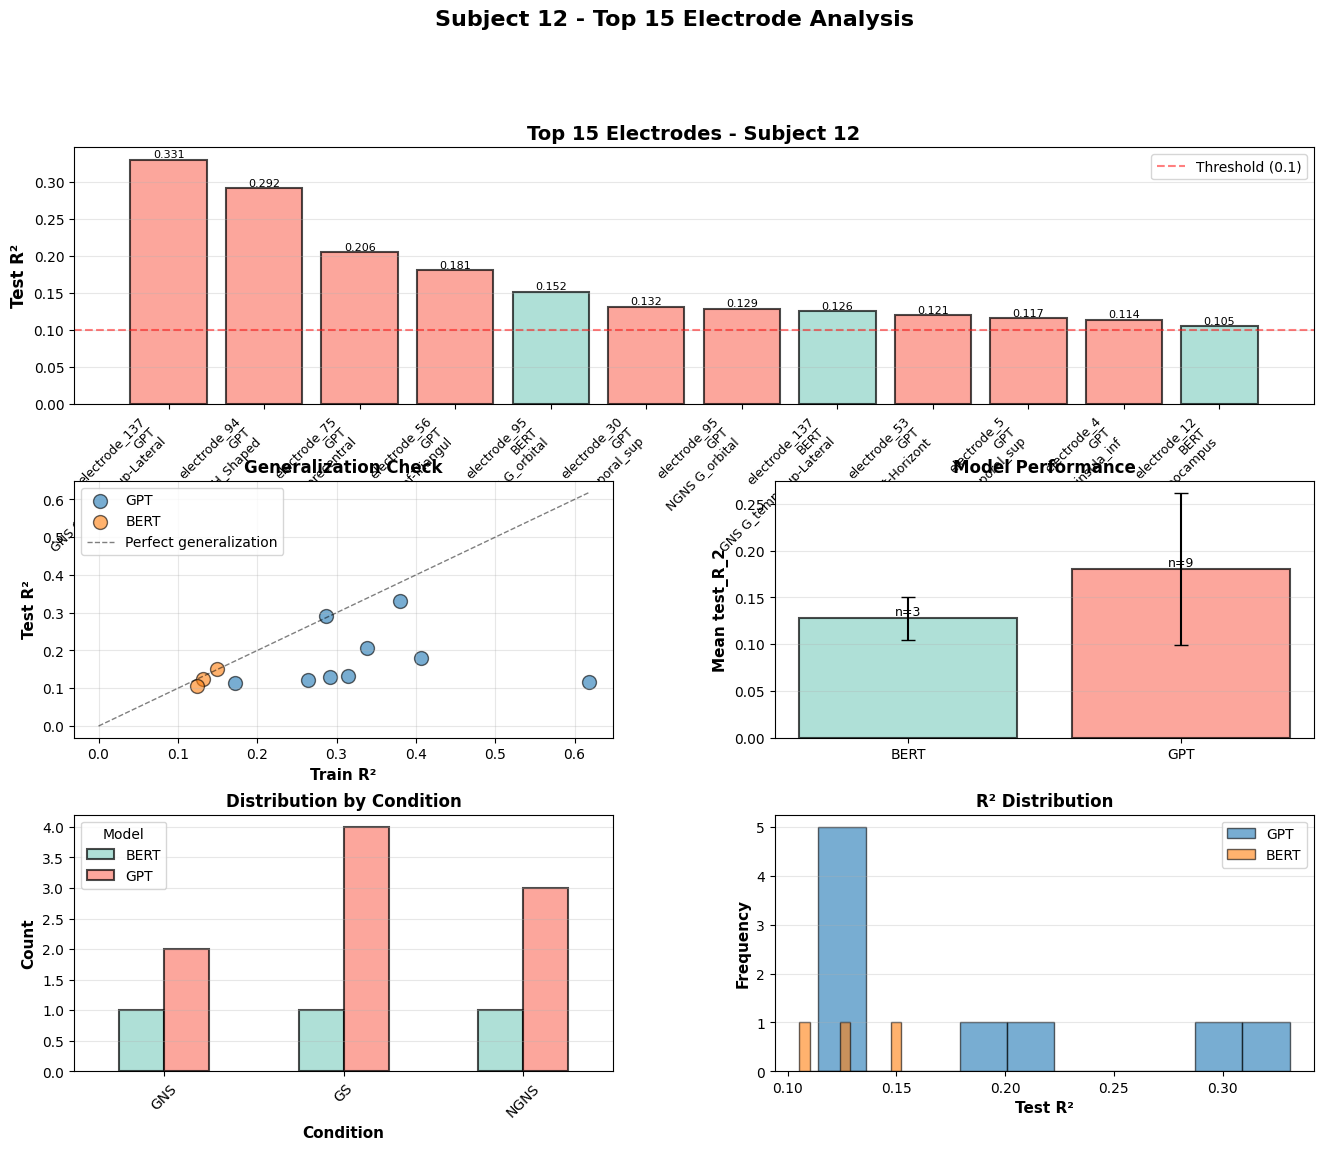


TOP 15 ELECTRODES SUMMARY - SUBJECT 12

Mean Test R²: 0.1671 ± 0.0740
Range: 0.1054 - 0.3307

Model Distribution:
model
GPT     9
BERT    3
Name: count, dtype: int64

Condition Distribution:
condition
GS      5
NGNS    4
GNS     3
Name: count, dtype: int64

2. Generating power visualizations for top 5 electrodes...
   Plotting electrode electrode_137 (index 137)...


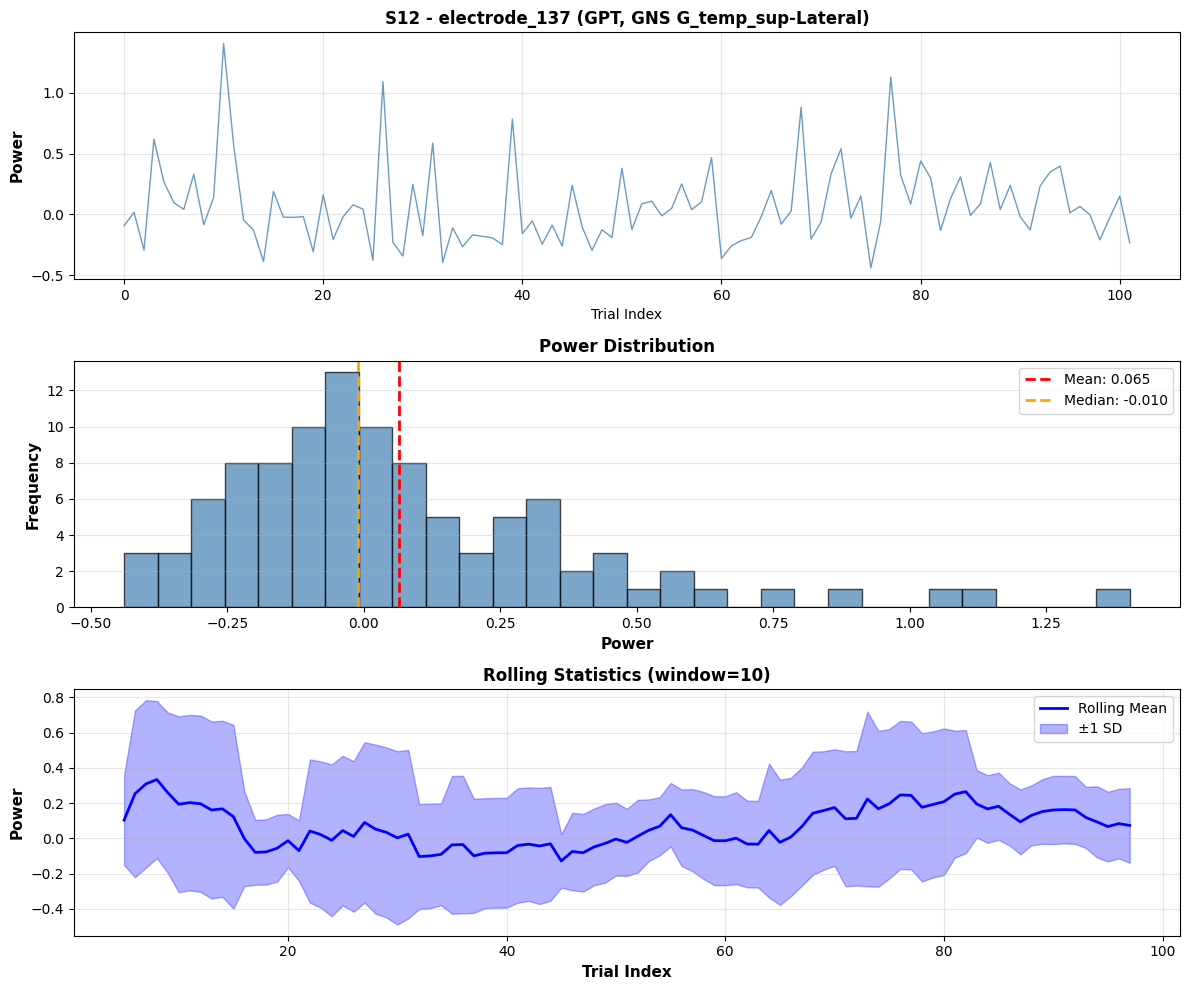


Electrode 137 - Power Statistics
Mean:   0.0645
Median: -0.0100
Std:    0.3286
Min:    -0.4390
Max:    1.4031
Range:  1.8421
   Plotting electrode electrode_94 (index 94)...


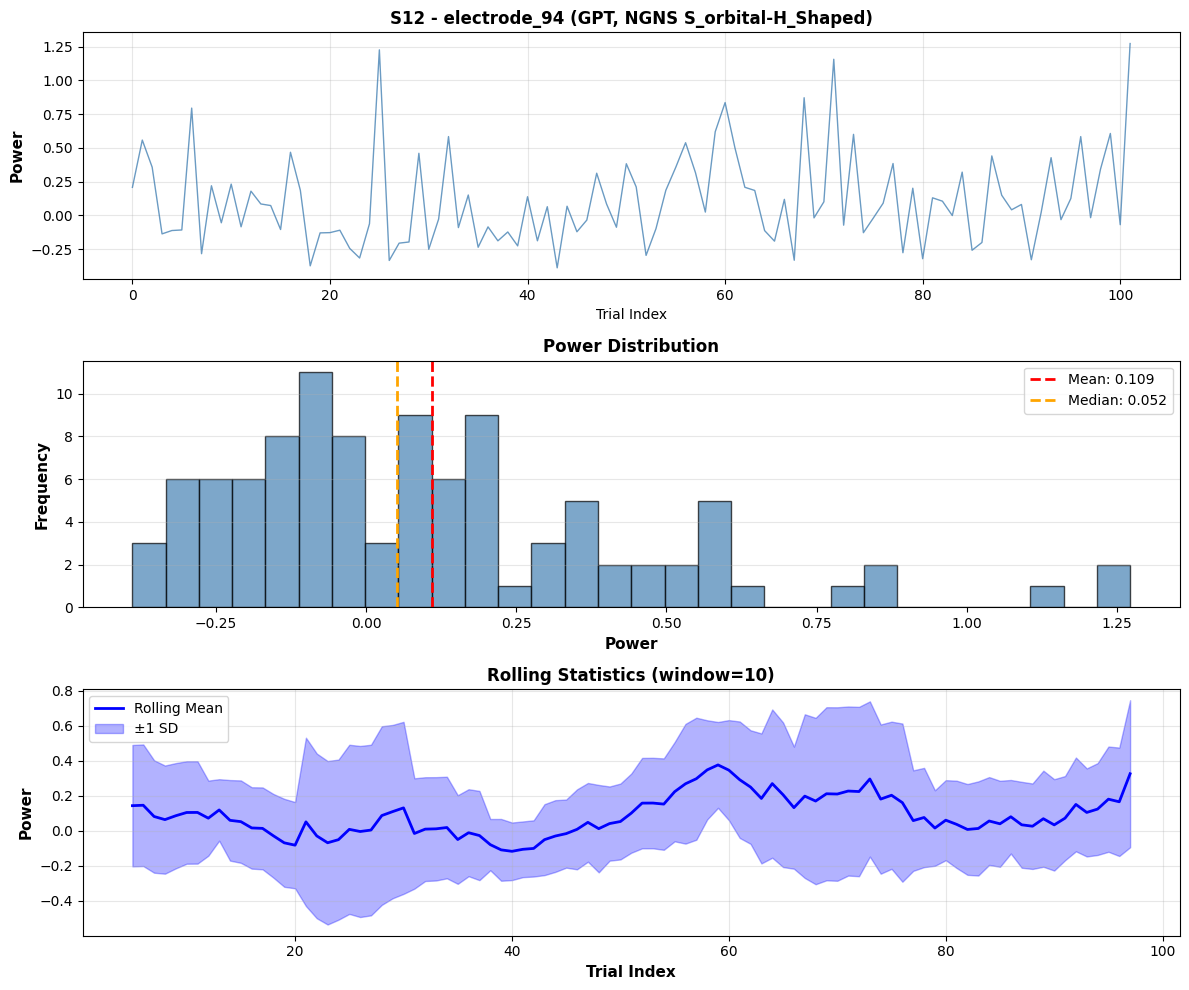


Electrode 94 - Power Statistics
Mean:   0.1090
Median: 0.0522
Std:    0.3449
Min:    -0.3890
Max:    1.2721
Range:  1.6611
   Plotting electrode electrode_75 (index 75)...


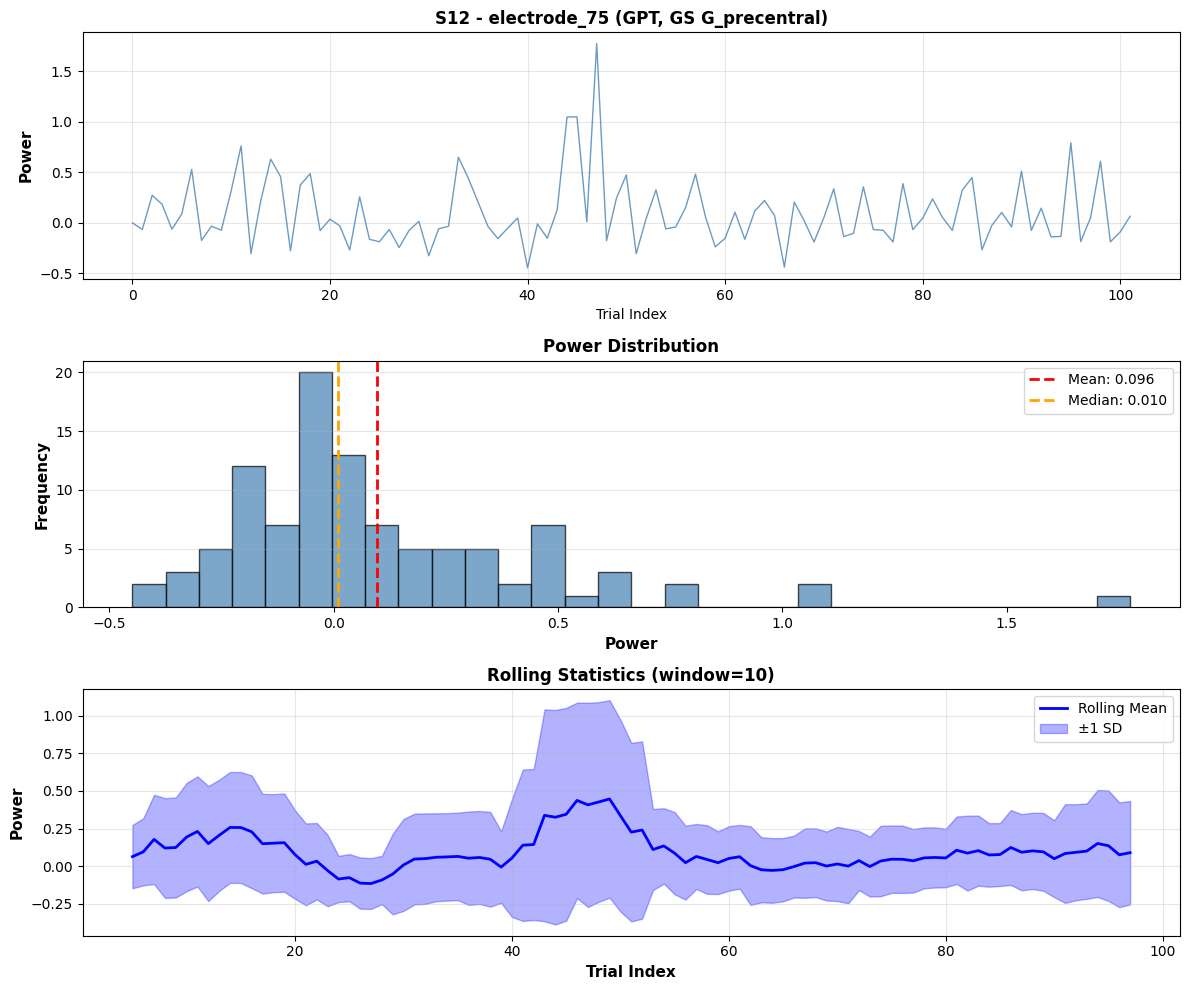


Electrode 75 - Power Statistics
Mean:   0.0959
Median: 0.0104
Std:    0.3374
Min:    -0.4487
Max:    1.7747
Range:  2.2234
   Plotting electrode electrode_56 (index 56)...


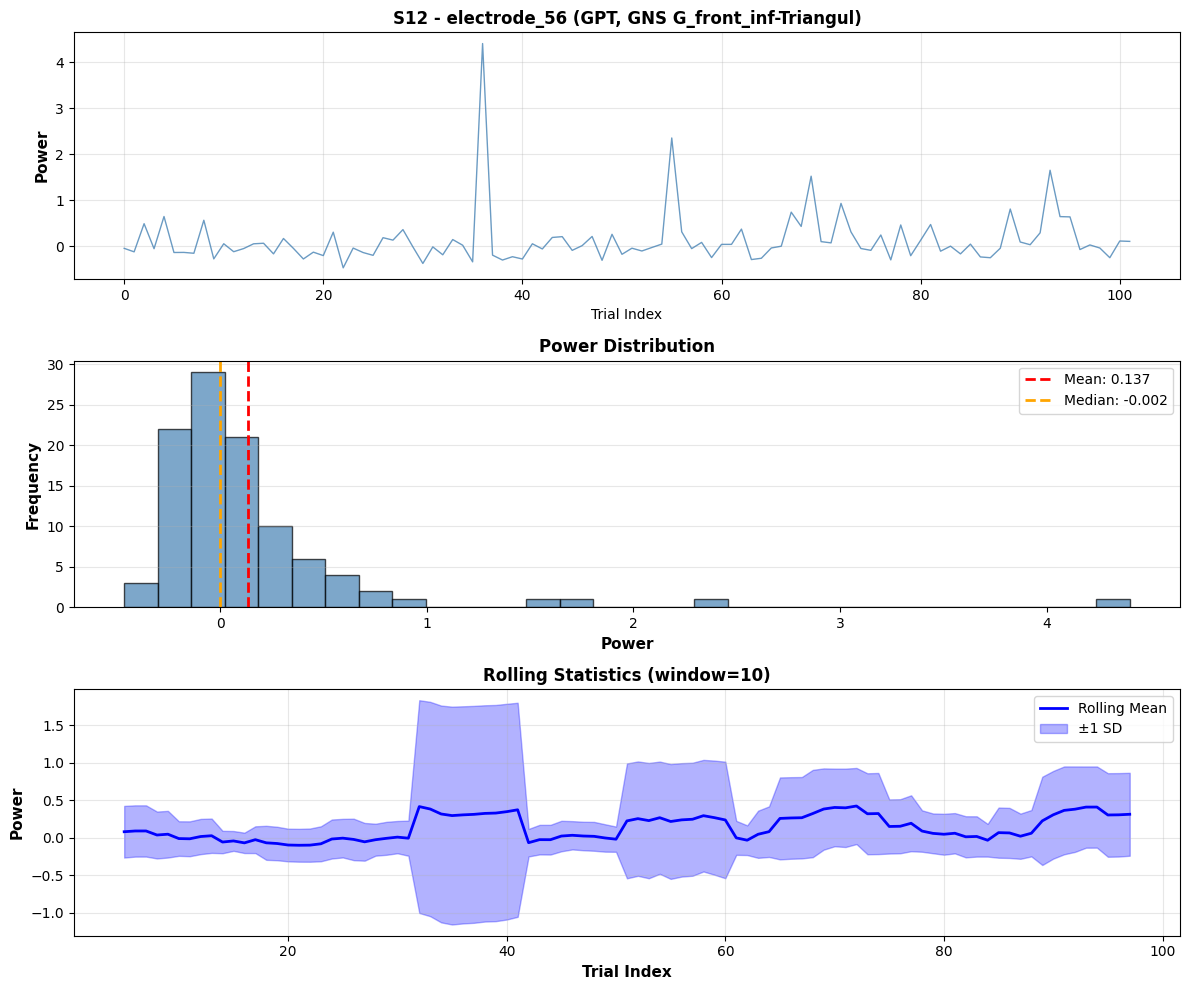


Electrode 56 - Power Statistics
Mean:   0.1369
Median: -0.0020
Std:    0.5905
Min:    -0.4639
Max:    4.4026
Range:  4.8665
   Plotting electrode electrode_95 (index 95)...


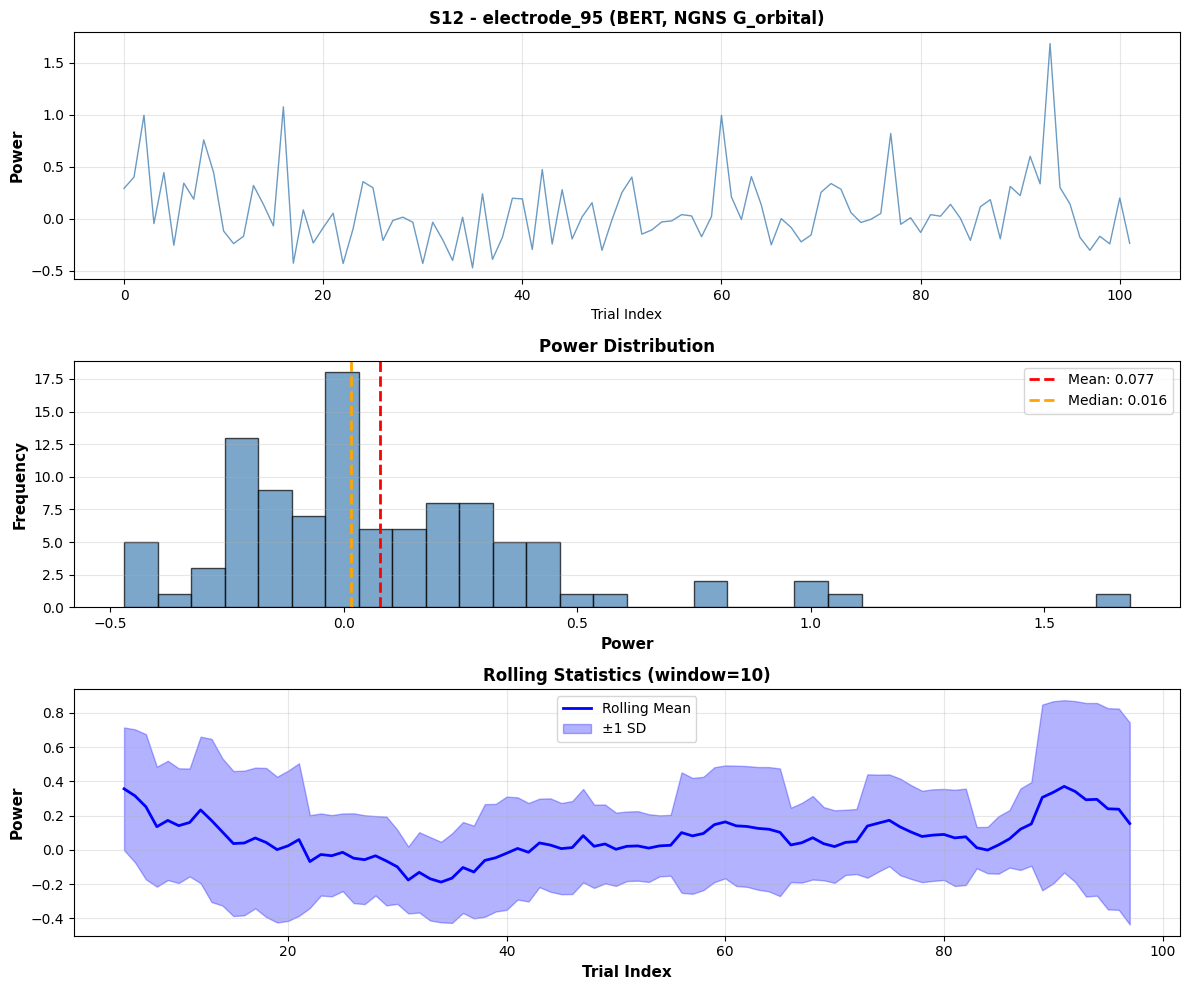


Electrode 95 - Power Statistics
Mean:   0.0773
Median: 0.0155
Std:    0.3435
Min:    -0.4706
Max:    1.6825
Range:  2.1532

3. Prediction plots require pipeline modification (skipping for now)
   See add_predictions_to_pipeline() for details

All visualizations saved to: results/plots/


In [48]:
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

import os

# Create output directory
os.makedirs('results/plots', exist_ok=True)

for sub in subjects_run:
    print(f"\n{'='*80}")
    print(f"VISUALIZING SUBJECT {sub}")
    print('='*80)
    
    # 1. Top electrodes summary (works with your current data)
    print("\n1. Generating top electrodes summary...")
    top_elecs = plot_top_electrodes_summary(
        saved_elecs, 
        sub, 
        top_n=15,
        metric='test_R_2',
        save_path=f'results/plots/S{sub}_top_electrodes.png'
    )
    
    # 2. Power/spectrogram visualizations (works with your current data)
    print(f"\n2. Generating power visualizations for top 5 electrodes...")
    
    # Load one of the condition results to get y data
    sub_files = find_files_with_pattern("results_objs", f"S{sub}")
    if len(sub_files) > 0:
        # Load the first condition's results
        first_result = pd.read_pickle(sub_files[0])
        y_data = first_result['y']
        
        # Visualize top 5 electrodes
        for i, (idx, row) in enumerate(top_elecs.head(5).iterrows()):
            elec_idx = int(row['Elec_index'])
            
            print(f"   Plotting electrode {row['electrode']} (index {elec_idx})...")
            plot_spectrogram_from_y(
                y_data, 
                elec_idx,
                title=f"S{sub} - {row['electrode']} ({row['model']}, {row['condition']} {row['parcLabel']})",
                save_path=f'results/plots/S{sub}_power_elec{i+1}.png'
            )
    else:
        print(f"   No results files found for Subject {sub}")
    
    print(f"\n3. Prediction plots require pipeline modification (skipping for now)")
    print(f"   See add_predictions_to_pipeline() for details")

print("\n" + "="*80)
print(f"All visualizations saved to: results/plots/")
print("="*80)

## Compare top electrodes to general population


STATISTICAL COMPARISON: HIGH-PERFORMING vs ALL ELECTRODES

SUBJECT 1

DESCRIPTIVE STATISTICS
High-performing electrodes (R² > 0.1):
  N = 14
  Mean = 0.1677
  Median = 0.1404
  SD = 0.0632
  Range = [0.1054, 0.3307]

All electrodes:
  N = 1980
  Mean = -4.4830
  Median = -0.0655
  SD = 64.9658
  Range = [-1961.0126, 0.3307]

Difference:
  Mean difference = 4.6508
  Median difference = 0.2059

STATISTICAL TESTS

1. Mann-Whitney U Test (non-parametric):
   U-statistic = 27622.00
   p-value = 0.000000 ***

2. Independent t-test (parametric):
   t-statistic = 0.27
   p-value = 0.394470 ns

3. Effect Size:
   Cohen's d = 0.0718 (negligible)

4. Permutation Test (10,000 permutations):
   Observed difference = 4.6508
   p-value = 0.000100 ***

SUBJECT 8

DESCRIPTIVE STATISTICS
High-performing electrodes (R² > 0.1):
  N = 12
  Mean = 0.1549
  Median = 0.1532
  SD = 0.0414
  Range = [0.1026, 0.2174]

All electrodes:
  N = 1260
  Mean = -0.1803
  Median = -0.0614
  SD = 0.8504
  Range = [-28.23

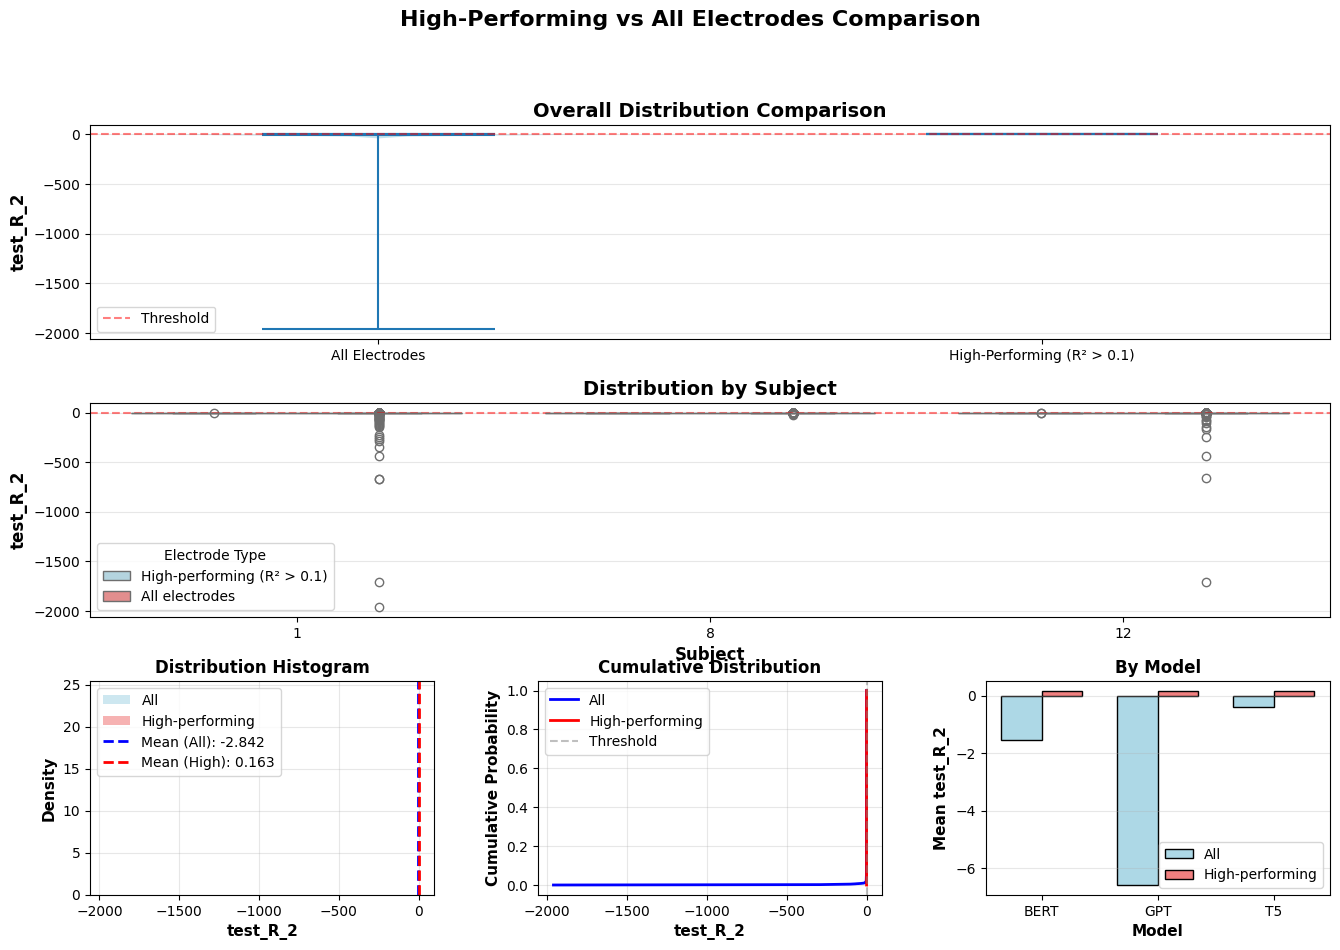


SUMMARY TABLE
 Subject  N (High-perf)  N (All) Mean (High-perf) Mean (All) Difference Cohen's d Mann-Whitney p t-test p Permutation p Significant?
       1             14     1980           0.1677    -4.4830     4.6508     0.072         0.0000   0.3945        0.0001      Yes ***
       8             12     1260           0.1549    -0.1803     0.3352     0.396         0.0000   0.0863        0.0001      Yes ***
      12             12     1404           0.1671    -2.9149     3.0820     0.060         0.0000   0.4175        0.0001      Yes ***

All results saved to: results/statistical_comparison


In [ ]:
#overall
"""
The Mann-Whitney U test (also known as the Wilcoxon Rank-Sum Test) is a non-parametric statistical test used to compare two independent groups to see if they likely come from the same population, testing for differences in their distributions, especially when data isn't normally distributed or is ordinal
"""
results, summary = run_full_comparison(saved_elecs, all_elecs)

## Brain Plotting (For most significant electrodes)


In [55]:
import mne
mne.viz.set_3d_backend("pyvistaqt", verbose=True)
print(mne.viz.get_3d_backend())

Using pyvistaqt 3d backend.
pyvistaqt


In [54]:
import pyvista
print(pyvista.global_theme.jupyter_backend)


trame



GENERATING BRAIN VISUALIZATIONS - SUBJECT 1

1. Creating brain plots by model...

BRAIN VISUALIZATIONS BY MODEL - SUBJECT 1

BERT: 5 electrodes
Plotting 5 electrodes above threshold 0.1
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`

BRAIN VISUALIZATION SUMMARY
Electrodes plotted: 5
Metric range: 0.105 - 0.251

Top 5 brain regions:
  S_front_inf: 1 electrodes
  S_temporal_inf: 1 electrodes
  G_and_S_cingul-Ant: 1 electrodes
  G_front_inf-Opercular: 1 electrodes
  Hippocampus: 1 electrodes

GPT: 8 electrodes
Plotting 8 electrodes above threshold 0.1
For automatic theme detection, "dar

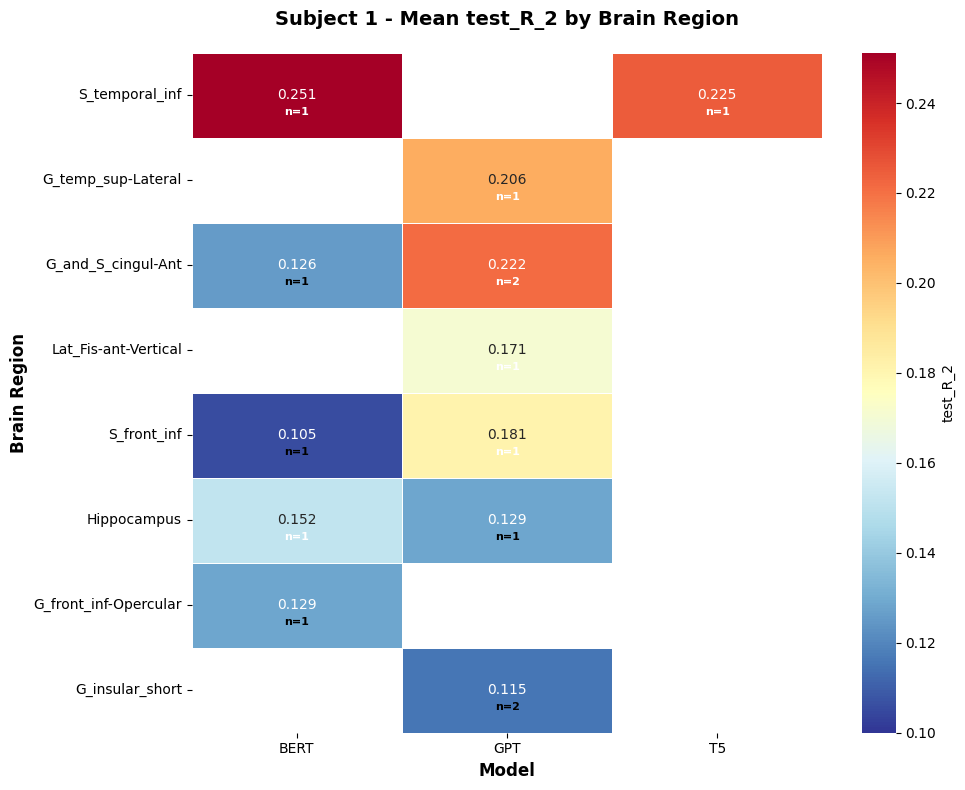


BRAIN REGION SUMMARY - SUBJECT 1

Top 10 regions by average test_R_2:
                           mean  count
parcLabel                             
S_temporal_inf         0.238174      2
G_temp_sup-Lateral     0.205736      1
G_and_S_cingul-Ant     0.189578      3
Lat_Fis-ant-Vertical   0.170667      1
S_front_inf            0.143396      2
Hippocampus            0.140369      2
G_front_inf-Opercular  0.128746      1
G_insular_short        0.115357      2

All brain visualizations saved to: results/brain_plots/S1

GENERATING BRAIN VISUALIZATIONS - SUBJECT 8

1. Creating brain plots by model...

BRAIN VISUALIZATIONS BY MODEL - SUBJECT 8

BERT: 3 electrodes
Plotting 3 electrodes above threshold 0.1
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! 

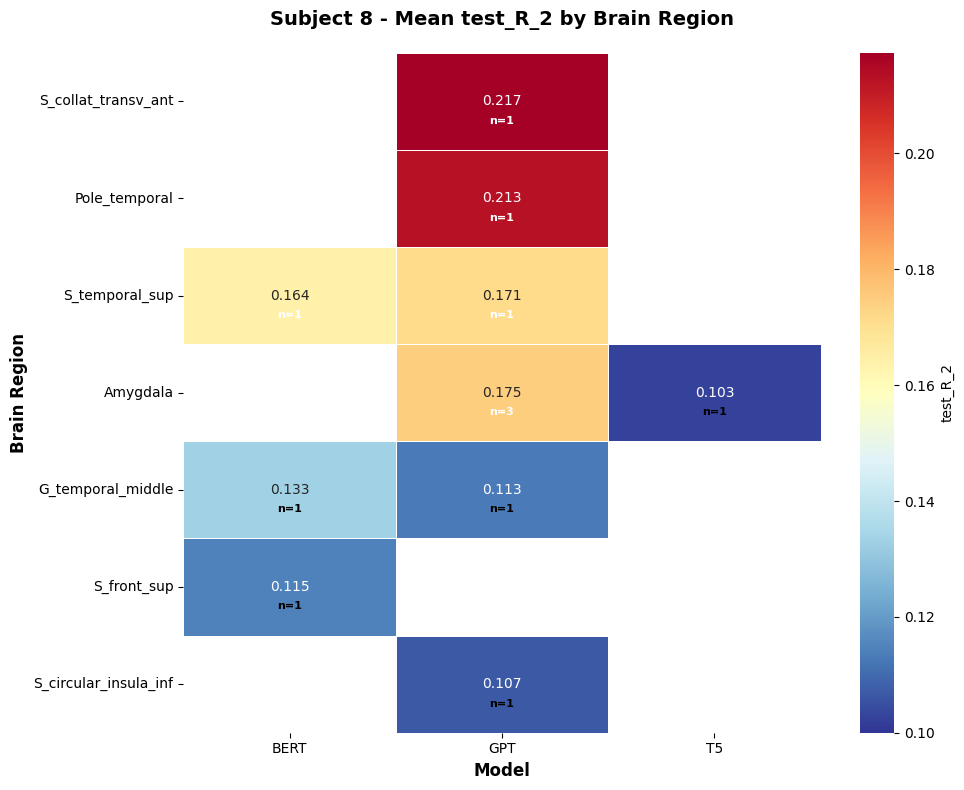


BRAIN REGION SUMMARY - SUBJECT 8

Top 10 regions by average test_R_2:
                           mean  count
parcLabel                             
S_collat_transv_ant    0.217388      1
Pole_temporal          0.212924      1
S_temporal_sup         0.167537      2
Amygdala               0.156573      4
G_temporal_middle      0.122960      2
S_front_sup            0.114657      1
S_circular_insula_inf  0.106727      1

All brain visualizations saved to: results/brain_plots/S8

GENERATING BRAIN VISUALIZATIONS - SUBJECT 12

1. Creating brain plots by model...

BRAIN VISUALIZATIONS BY MODEL - SUBJECT 12

BERT: 3 electrodes
Plotting 3 electrodes above threshold 0.1
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install 

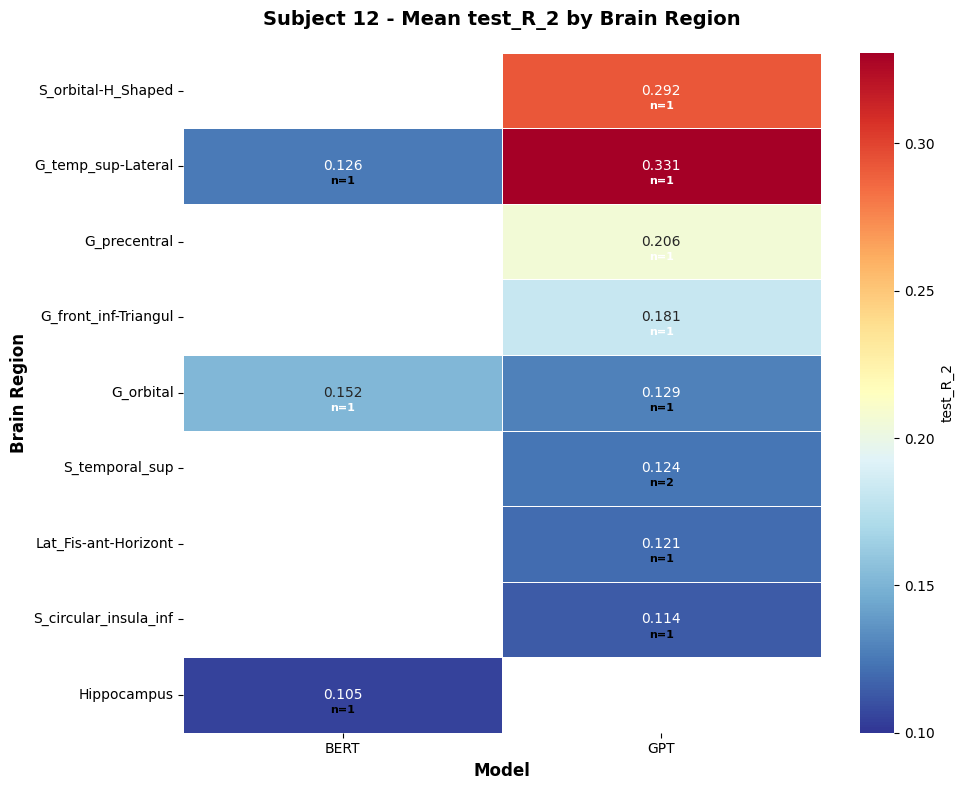


BRAIN REGION SUMMARY - SUBJECT 12

Top 10 regions by average test_R_2:
                           mean  count
parcLabel                             
S_orbital-H_Shaped     0.292425      1
G_temp_sup-Lateral     0.228216      2
G_precentral           0.205736      1
G_front_inf-Triangul   0.181392      1
G_orbital              0.140369      2
S_temporal_sup         0.124127      2
Lat_Fis-ant-Horizont   0.120561      1
S_circular_insula_inf  0.114178      1
Hippocampus            0.105400      1

All brain visualizations saved to: results/brain_plots/S12


2026-01-19 15:34:13.327 Python[40444:1007144] Warning: Window move completed without beginning


In [ ]:
generate_all_brain_visualizations(saved_elecs, subjects_run=[1, 8, 12])